In [ ]:
# Copyright 2024 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Intro to Grounding with Gemini in Vertex AI

<table align="left">
  <td style="text-align: center">
    <a href="https://colab.research.google.com/github/GoogleCloudPlatform/generative-ai/blob/main/gemini/grounding/intro-grounding-gemini.ipynb">
      <img width="32px" src="https://www.gstatic.com/pantheon/images/bigquery/welcome_page/colab-logo.svg" alt="Google Colaboratory logo"><br> Run in Colab
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https:%2F%2Fraw.githubusercontent.com%2FGoogleCloudPlatform%2Fgenerative-ai%2Fmain%2Fgemini%2Fgrounding%2Fintro-grounding-gemini.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Google Cloud Colab Enterprise logo"><br> Run in Colab Enterprise
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/grounding/intro-grounding-gemini.ipynb">
      <img width="32px" src="https://www.svgrepo.com/download/217753/github.svg" alt="GitHub logo"><br> View on GitHub
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/workbench/deploy-notebook?download_url=https://raw.githubusercontent.com/GoogleCloudPlatform/generative-ai/main/gemini/grounding/intro-grounding-gemini.ipynb">
      <img src="https://www.gstatic.com/images/branding/gcpiconscolors/vertexai/v1/32px.svg" alt="Vertex AI logo"><br> Open in Vertex AI Workbench
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://goo.gle/4jeQyFS">
      <img width="32px" src="https://cdn.qwiklabs.com/assets/gcp_cloud-e3a77215f0b8bfa9b3f611c0d2208c7e8708ed31.svg" alt="Google Cloud logo"><br> Open in  Cloud Skills Boost
    </a>
  </td>
</table>

<div style="clear: both;"></div>

<b>Share to:</b>

<a href="https://www.linkedin.com/sharing/share-offsite/?url=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/grounding/intro-grounding-gemini.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/8/81/LinkedIn_icon.svg" alt="LinkedIn logo">
</a>

<a href="https://bsky.app/intent/compose?text=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/grounding/intro-grounding-gemini.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/7/7a/Bluesky_Logo.svg" alt="Bluesky logo">
</a>

<a href="https://twitter.com/intent/tweet?url=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/grounding/intro-grounding-gemini.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/5/5a/X_icon_2.svg" alt="X logo">
</a>

<a href="https://reddit.com/submit?url=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/grounding/intro-grounding-gemini.ipynb" target="_blank">
  <img width="20px" src="https://redditinc.com/hubfs/Reddit%20Inc/Brand/Reddit_Logo.png" alt="Reddit logo">
</a>

<a href="https://www.facebook.com/sharer/sharer.php?u=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/grounding/intro-grounding-gemini.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/5/51/Facebook_f_logo_%282019%29.svg" alt="Facebook logo">
</a>            

| Original Authors |
| --- |
| [Holt Skinner](https://github.com/holtskinner) |
| [Kristopher Overholt](https://github.com/koverholt)|
| Edited by |
| dvanh@google.com |

## Overview

[Grounding in Vertex AI](https://cloud.google.com/vertex-ai/generative-ai/docs/multimodal/ground-gemini) lets you use generative text models to generate content grounded in your own documents and data. This capability lets the model access information at runtime that goes beyond its training data. By grounding model responses in Google Search results or data stores within [Vertex AI Search](https://cloud.google.com/generative-ai-app-builder/docs/enterprise-search-introduction), LLMs that are grounded in data can produce more accurate, up-to-date, and relevant responses.

Grounding provides the following benefits:

- Reduces model hallucinations (instances where the model generates content that isn't factual)
- Anchors model responses to specific information, documents, and data sources
- Enhances the trustworthiness, accuracy, and applicability of the generated content

You can configure two different sources of grounding in Vertex AI:

1. Google Search results for data that is publicly available and indexed.
   - If you use this service in a production application, you will also need to [use a Google Search entry point](https://cloud.google.com/vertex-ai/generative-ai/docs/multimodal/grounding-search-entry-points).
2. [Data stores in Vertex AI Search](https://cloud.google.com/generative-ai-app-builder/docs/create-datastore-ingest), which can include your own data in the form of website data, unstructured data, or structured data

### Objective

In this tutorial, you learn how to:

- Generate LLM text and chat model responses grounded in Google Search results
- Compare the results of ungrounded LLM responses with grounded LLM responses
- Create and use a data store in Vertex AI Search to ground responses in custom documents and data
- Generate LLM text and chat model responses grounded in Vertex AI Search results

This tutorial uses the following Google Cloud AI services and resources:

- Vertex AI
- Vertex AI Search

The steps performed include:

- Configuring the LLM and prompt for various examples
- Sending example prompts to generative text and chat models in Vertex AI
- Setting up a data store in Vertex AI Search with your own data
- Sending example prompts with various levels of grounding (no grounding, web grounding, data store grounding)

## Before you begin

### Set up your Google Cloud project

**The following steps are required, regardless of your notebook environment.**

1. [Select or create a Google Cloud project](https://console.cloud.google.com/cloud-resource-manager). When you first create an account, you get a $300 free credit towards your compute/storage costs.
1. [Make sure that billing is enabled for your project](https://cloud.google.com/billing/docs/how-to/modify-project).
1. Enable the [Vertex AI and Vertex AI Search APIs](https://console.cloud.google.com/flows/enableapi?apiid=aiplatform.googleapis.com,discoveryengine.googleapis.com).
1. If you are running this notebook locally, you need to install the [Cloud SDK](https://cloud.google.com/sdk).

### Install Google Gen AI SDK for Python

Install the following packages required to execute this notebook.

In [ ]:
%pip install --upgrade --quiet google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.5/241.5 kB 11.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-server 1.24.0 requires anyio<4,>=3.1.0, but you have anyio 4.11.0 which is incompatible.


### (Skip for Colab Ent/Workbench)Authenticate your Google Cloud account

If you are running this notebook on Google Colab, you will need to authenticate your environment. To do this, run the new cell below. This step is not required if you are using Vertex AI Workbench.

In [ ]:
# import sys

# if "google.colab" in sys.modules:
#     # Authenticate user to Google Cloud
#     from google.colab import auth

#     auth.authenticate_user()

### Set Google Cloud project information and create client

To get started using Vertex AI, you must have an existing Google Cloud project and [enable the Vertex AI API](https://console.cloud.google.com/flows/enableapi?apiid=aiplatform.googleapis.com).

Learn more about [setting up a project and a development environment](https://cloud.google.com/vertex-ai/docs/start/cloud-environment).

**If you don't know your project ID**, try the following:
* Run `gcloud config list`.
* Run `gcloud projects list`.
* See the support page: [Locate the project ID](https://support.google.com/googleapi/answer/7014113)

You can also change the `LOCATION` variable used by Vertex AI. Learn more about [Vertex AI regions](https://cloud.google.com/vertex-ai/docs/general/locations).

In [ ]:
PROJECT_ID= !(gcloud config get-value core/project)
PROJECT_ID = PROJECT_ID[0]
print(PROJECT_ID)


kubernetes-demo-dva


In [ ]:
import os
LOCATION = "global"

from google import genai

client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

### Import libraries

In [ ]:
from IPython.core.display import Markdown
from IPython.display import display
from google.genai.types import (
    EnterpriseWebSearch,
    GenerateContentConfig,
    GenerateContentResponse,
    GoogleMaps,
    GoogleSearch,
    LatLng,
    Part,
    Retrieval,
    RetrievalConfig,
    Tool,
    ToolConfig,
    VertexAISearch,
)

### Helper functions

In [ ]:
def print_grounding_data(response: GenerateContentResponse) -> None:
    """Prints Gemini response with grounding citations in Markdown format."""
    if not (response.candidates and response.candidates[0].grounding_metadata):
        print("Response does not contain grounding metadata.")
        display(Markdown(response.text))
        return

    grounding_metadata = response.candidates[0].grounding_metadata
    markdown_parts = []

    # Citation indexes are in bytes
    ENCODING = "utf-8"
    text_bytes = response.text.encode(ENCODING)
    last_byte_index = 0

    if grounding_metadata.grounding_supports:
        for support in grounding_metadata.grounding_supports:
            markdown_parts.append(
                text_bytes[last_byte_index : support.segment.end_index].decode(ENCODING)
            )

            # Generate and append citation footnotes (e.g., "[1][2]")
            footnotes = "".join([f"[{i + 1}]" for i in support.grounding_chunk_indices])
            markdown_parts.append(f" {footnotes}")

            # Update index for the next segment
            last_byte_index = support.segment.end_index

    # Append any remaining text after the last citation
    if last_byte_index < len(text_bytes):
        markdown_parts.append(text_bytes[last_byte_index:].decode(ENCODING))

    markdown_parts.append("\n\n----\n## Grounding Sources\n")

    if grounding_metadata.grounding_chunks:
        # Build Grounding Sources Section
        markdown_parts.append("### Grounding Chunks\n")
        for i, chunk in enumerate(grounding_metadata.grounding_chunks, start=1):
            context = chunk.web or chunk.retrieved_context or chunk.maps
            if not context:
                continue

            uri = context.uri
            title = context.title or "Source"

            # Convert GCS URIs to public HTTPS URLs
            if uri and uri.startswith("gs://"):
                uri = uri.replace(
                    "gs://", "https://storage.googleapis.com/", 1
                ).replace(" ", "%20")

            markdown_parts.append(f"{i}. [{title}]({uri})\n")
            if hasattr(context, "place_id") and context.place_id:
                markdown_parts.append(f"    - Place ID: `{context.place_id}`\n\n")
            if hasattr(context, "text") and context.text:
                markdown_parts.append(f"{context.text}\n\n")

    # Add Search/Retrieval Queries
    if grounding_metadata.web_search_queries:
        markdown_parts.append(
            f"\n**Web Search Queries:** {grounding_metadata.web_search_queries}\n"
        )
        if grounding_metadata.search_entry_point:
            markdown_parts.append(
                f"\n**Search Entry Point:**\n{grounding_metadata.search_entry_point.rendered_content}\n"
            )
    elif grounding_metadata.retrieval_queries:
        markdown_parts.append(
            f"\n**Retrieval Queries:** {grounding_metadata.retrieval_queries}\n"
        )

    display(Markdown("".join(markdown_parts)))

*Initialize* the Gemini model from Vertex AI:

In [ ]:
MODEL_ID = "gemini-2.5-flash"  # @param {type: "string"}

## Example: Grounding with Google Search results

In this example, you'll compare LLM responses with no grounding with responses that are grounded in the results of a Google Search. You'll ask a question about a the most recent solar eclipse.

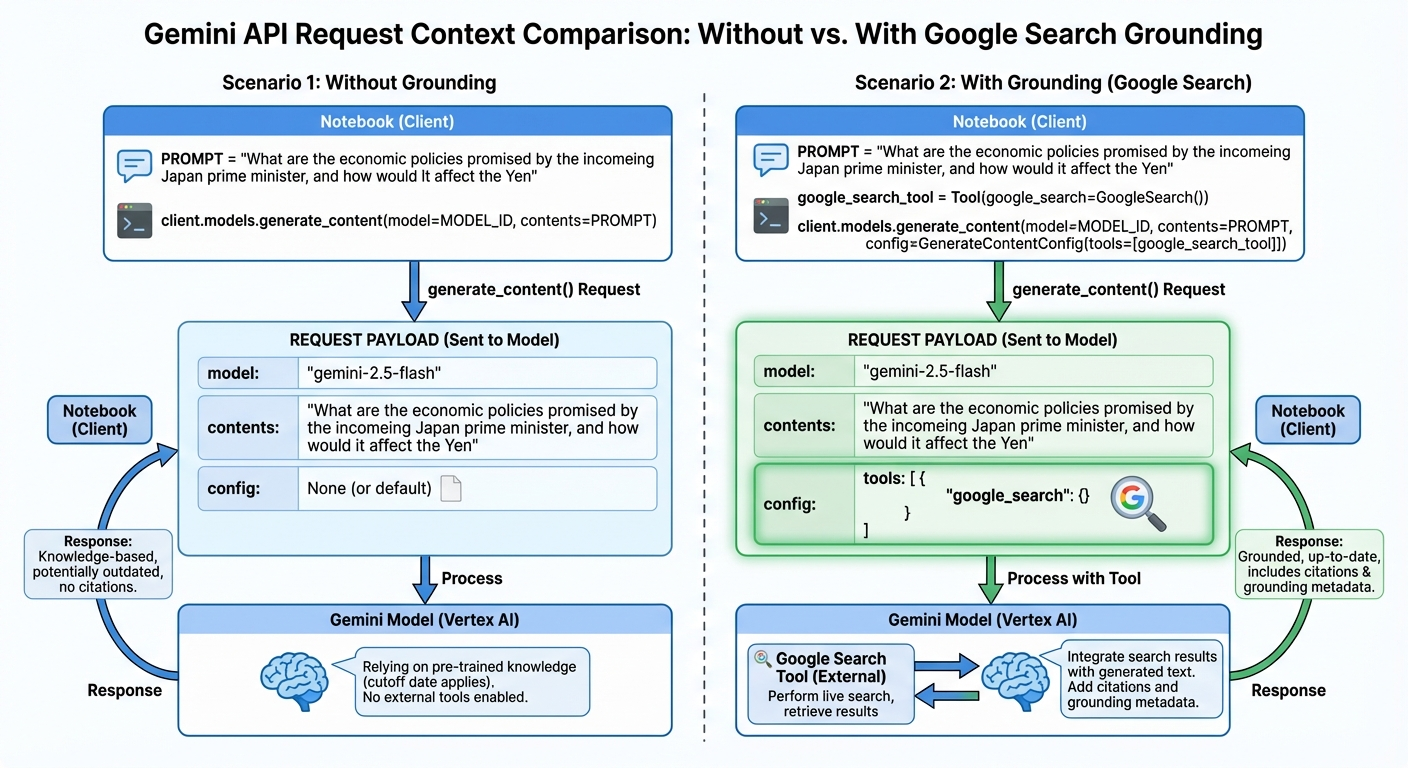

In [ ]:
PROMPT = "What are the economic policies promised by the incomeing Japan prime minister, and how would it affect the Yen"

### Text generation without grounding

Make a prediction request to the LLM with no grounding:

In [ ]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents=PROMPT,
)

display(Markdown(response.text))

As of my last update, there isn't an "incoming" Japanese Prime Minister; Fumio Kishida is currently the Prime Minister. However, if we assume a hypothetical *new* Prime Minister were to take office, their economic policies would likely revolve around addressing Japan's persistent challenges while adapting to global trends.

Drawing from current political discourse within the ruling Liberal Democratic Party (LDP) and the broader economic landscape, here's a plausible set of policies an incoming PM might promise, and their potential impact on the Yen:

---

**Likely Economic Policies of a Hypothetical Incoming Japanese Prime Minister**

A new PM would likely aim to build upon or pivot from "Abenomics" (Monetary easing, Fiscal stimulus, Structural reform) while incorporating newer priorities.

1.  **Sustainable Wage Growth and Inflation:**
    *   **Policy:** A strong push for corporations to raise wages consistently and significantly. This might involve tax incentives for companies increasing salaries, continued pressure on business federations, and a focus on labor market reforms to encourage better pay. The ultimate goal is to achieve stable, demand-driven inflation (around 2%) to fully exit the deflationary mindset.
    *   **Link to BoJ:** This policy would be seen as paving the way for the Bank of Japan (BoJ) to eventually normalize its ultra-loose monetary policy (e.g., exiting Yield Curve Control, raising interest rates).

2.  **Green Transformation (GX) and Digital Transformation (DX):**
    *   **Policy:** Massive public and private investment in decarbonization technologies (renewables, hydrogen, batteries, carbon capture), energy efficiency, and digital infrastructure (AI, cloud computing, cybersecurity). This includes R&D support, subsidies, and regulatory streamlining.
    *   **Goal:** To boost Japan's long-term growth potential, enhance competitiveness, and address climate change.

3.  **Fiscal Discipline and Targeted Spending:**
    *   **Policy:** While the PM might promise continued fiscal stimulus to support growth, there would likely be an emphasis on "quality" spending – targeting areas like GX, DX, childcare support, and defense, rather than broad-based stimulus. There might also be a rhetoric around eventually tackling Japan's massive public debt, perhaps through long-term growth or more efficient spending rather than immediate austerity.
    *   **Goal:** Balance short-term growth needs with long-term fiscal sustainability.

4.  **Structural Reforms for Competitiveness:**
    *   **Policy:**
        *   **Labor Market:** Reforms to increase flexibility, encourage mobility, support reskilling, and promote women's participation.
        *   **Corporate Governance:** Further reforms to improve profitability, attract foreign investment, and encourage companies to deploy their vast cash reserves.
        *   **Startups & Innovation:** Support for new businesses, venture capital, and cutting-edge research.
        *   **Deregulation:** Reducing bureaucratic hurdles in key growth sectors.
    *   **Goal:** Enhance Japan's productivity, innovation, and international competitiveness.

5.  **Economic Security and Supply Chain Resilience:**
    *   **Policy:** Strengthening critical supply chains (e.g., semiconductors, rare earths), promoting domestic production in strategic sectors, and safeguarding sensitive technologies, potentially through subsidies or investment screening.
    *   **Goal:** Reduce vulnerability to geopolitical risks and secure essential resources/technologies.

6.  **Addressing Demographic Challenges:**
    *   **Policy:** Enhanced support for childcare, education, and policies aimed at boosting the birth rate and supporting the elderly. This is less direct economic policy but critical for long-term labor supply and demand.

---

**How These Policies Would Affect the Yen**

The impact on the Yen would largely depend on **how quickly and effectively these policies are perceived to achieve sustainable inflation and whether they signal an eventual shift in the Bank of Japan's monetary policy.**

1.  **Strong Push for Wage Growth & Inflation:**
    *   **Impact:** Potentially **Yen bullish (strengthening)** in the medium to long term. If the market believes the PM's initiatives will genuinely lead to sustained wage increases and inflation, it increases the likelihood of the BoJ exiting Yield Curve Control (YCC) and eventually raising interest rates. Higher interest rates (or the expectation of them) would make the Yen more attractive to investors, narrowing the interest rate differential with other major currencies.

2.  **Green Transformation (GX) & Digital Transformation (DX):**
    *   **Impact:** Potentially **Yen bullish** in the long term. Successful implementation of these policies could boost Japan's productivity and economic growth potential, attracting foreign direct investment (FDI). A stronger, more innovative economy generally supports a stronger currency. In the short term, if these initiatives require significant imports of technology or raw materials, there could be a temporary downward pressure on the Yen.

3.  **Fiscal Discipline & Targeted Spending:**
    *   **Impact:** Mixed.
        *   **Targeted growth spending (GX, DX, etc.):** If it genuinely boosts growth and reduces the need for constant stimulus, it could be **Yen positive** by improving fiscal health and long-term economic prospects.
        *   **Continued large-scale debt issuance:** Could be **Yen negative** if it raises concerns about Japan's fiscal sustainability, although Japan's debt is largely held domestically, mitigating some immediate risks.

4.  **Structural Reforms for Competitiveness:**
    *   **Impact:** **Yen bullish** in the long term. These reforms make Japan a more attractive place to invest, improving corporate profitability and overall economic efficiency. This draws capital into Japan, strengthening the Yen. Short-term impact is usually minimal.

5.  **Economic Security & Supply Chain Resilience:**
    *   **Impact:** Potentially **Yen bullish**. Investment in domestic production and strategic sectors could attract both domestic and foreign capital, contributing to a more resilient and self-sufficient economy, which is generally positive for the currency.

**Overall Summary of Yen Impact:**

*   **Short-term (immediate PM announcement to 6-12 months):**
    *   If the new PM emphasizes continued fiscal support without an immediate push for BoJ tightening (which is common for new PMs), the Yen might see **limited strengthening or even continued weakness** as interest rate differentials persist.
    *   However, any strong rhetoric suggesting confidence in achieving the 2% inflation target and paving the way for eventual BoJ policy normalization could lead to **some Yen appreciation** as markets adjust their expectations.

*   **Medium to Long-term (1-3+ years):**
    *   The **most significant factor for Yen appreciation** would be the successful implementation of policies that lead to **sustained wage growth and inflation**, allowing the BoJ to finally normalize its monetary policy. If the PM can achieve this, the Yen would likely see **substantial strengthening**.
    *   Successful structural reforms and investments in GX/DX that genuinely boost Japan's long-term growth potential would also contribute to a **stronger Yen**.

In essence, the Yen's direction under a new PM would critically hinge on the market's perception of how close Japan is to sustainably escaping deflation and whether the BoJ can pivot away from its ultra-loose monetary policy. The PM's policies would be judged primarily on their ability to create the conditions for that pivot.

### Text generation grounded in Google Search results

You can add the `tools` keyword argument with a `Tool` including `GoogleSearch` to instruct Gemini to first perform a Google Search with the prompt, then construct an answer based on the web search results.

The search queries and [Search Entry Point](https://cloud.google.com/vertex-ai/generative-ai/docs/multimodal/grounding-search-entry-points) are available for each `Candidate` in the response.

In [ ]:
PROMPT = "What are the economic policies promised by the incomeing Japan prime minister, and how would it affect the Yen"

google_search_tool = Tool(google_search=GoogleSearch())

response = client.models.generate_content(
    model=MODEL_ID,
    contents=PROMPT,
    config=GenerateContentConfig(tools=[google_search_tool]),
)

print_grounding_data(response)

Sanae Takaichi assumed office as Japan's Prime Minister on October 21, 2025, becoming the nation's first female leader [1][2][3][4][5][6][7]. Her administration's economic policies are expected to largely align with "Abenomics," the economic strategy of her mentor, the late Prime Minister Shinzo Abe, which focused on fiscal expansion, monetary easing, and structural reforms [8].

Key economic policies and priorities of Prime Minister Takaichi include:

*   **Economic Package as Top Priority**: Takaichi has stated that an economic package is a top priority for her administration, though specific details of this package are yet to be fully outlined [9]. This suggests a continued focus on stimulating economic growth.
*   **Fiscal Expansion and Monetary Easing**: Her alignment with "Abenomics" indicates a likely continuation of expansionary fiscal policies and accommodative monetary policy, which typically involves low interest rates and quantitative easing to combat deflation and stimulate economic activity [8]. Japan is currently grappling with stubborn inflation and record public debt, which will be challenges for her administration [5].
*   **Defense Spending Increase**: Takaichi has pledged to accelerate Japan's defense buildup, aiming to reach an annual defense spending target of 2% of the gross domestic product (GDP) by March 2026, ahead of schedule [10]. This significant increase in government spending will contribute to fiscal expansion.
*   **State-backed Innovation and Strategic Autonomy**: The policy landscape under Takaichi is shifting towards state-backed innovation and strategic autonomy. This includes early fiscal support for healthcare, making the AI sector a national strategic priority anchored in economic security, and opening the defense industry to new dual-use and technology partnerships under expanded spending [6].
*   **Addressing Cost-of-Living Issues**: While the details are sparse, other candidates in the LDP leadership race, including Takaichi, have focused on how to revive Japan's economy after decades of stagnation and address the cost-of-living crisis [8].

**Potential Effects on the Yen:**

The economic policies outlined could have several effects on the Japanese Yen:

*   **Continued Monetary Easing**: If Takaichi's administration continues with expansionary monetary policies similar to Abenomics, maintaining low interest rates while other major economies potentially raise theirs, this could lead to a widening interest rate differential. A larger differential typically makes the Yen less attractive to investors seeking higher returns, potentially leading to further **weakening of the Yen**.
*   **Fiscal Expansion and Government Debt**: Increased government spending, particularly on defense and economic packages, will likely add to Japan's already record public debt [10][5]. While fiscal expansion can stimulate the economy, concerns about the sustainability of public debt can sometimes put downward pressure on a currency if investor confidence wanes. However, in the short term, increased government spending could also boost economic activity, which might be seen positively.
*   **Inflation Targeting**: If the policies are successful in generating sustained inflation, moving away from deflation, and the Bank of Japan eventually shifts towards a tighter monetary policy, this could lead to a **strengthening of the Yen**. However, the immediate focus appears to be on economic stimulation and managing existing inflation [5].
*   **Investor Confidence**: Policies promoting state-backed innovation and strategic autonomy, if perceived as beneficial for long-term economic growth and stability, could attract foreign investment, which could indirectly support the Yen. Conversely, political instability due to a fragile coalition government, as Takaichi inherits, could deter investment [4][5].

In summary, given the emphasis on continuing expansionary economic policies and increased government spending, a potential initial outcome could be a continuation of the **Yen's weakness**, particularly if monetary easing persists and interest rate differentials remain wide. However, the long-term impact will depend on the effectiveness of these policies in achieving sustainable economic growth and managing inflation and debt.Sanae Takaichi, who assumed office as Japan's Prime Minister on October 21, 2025, has outlined an economic agenda largely echoing the "Abenomics" policies of the late Shinzo Abe, with a strong emphasis on proactive fiscal spending and a coordinated, accommodative monetary policy. Her economic platform, sometimes referred to as "Sakaenomics," aims to combat inflation and foster a strong, resilient economy [11][12].

**Key Economic Policies Promised by Prime Minister Sanae Takaichi:**

*   **Aggressive Fiscal Spending and Stimulus:** Takaichi has declared the fight against inflation and confronting soaring living costs as her administration's top priority [11][13]. She is preparing an economic stimulus package, expected to exceed ¥13.9 trillion, aimed at easing pressure on households and investing in growth industries [11][14][15].
*   **Tax Relief Measures:** To alleviate the burden of rising prices, Takaichi plans to abolish the provisional gasoline tax rate and raise the income tax exemption threshold from ¥1.03 million to ¥1.6 million [11][16]. Her administration also intends to introduce a new system combining income tax deductions and cash benefits for households [11].
*   **Strategic Investments for Growth:** A core focus of her growth strategy involves significant government investment in critical strategic sectors. These "crisis management investments" include artificial intelligence, semiconductors, nuclear fusion, biotechnology, and defense [11][16][17].
*   **Increased Defense Spending:** Takaichi has pledged to accelerate Japan's military buildup, aiming to reach an annual defense spending target of 2% of GDP by fiscal year 2025, two years ahead of the previous target [11][16][18].
*   **"Responsible Proactive Fiscal Policy":** While advocating for fiscal expansion, Takaichi emphasizes "responsible and proactive fiscal policy" focused on reducing the ratio of government debt to GDP rather than solely targeting a primary balance surplus [11][19]. She has indicated a willingness to issue deficit bonds when necessary for important measures [20].
*   **Monetary Policy Coordination with BOJ:** Takaichi stresses the importance of coordination between the government and the Bank of Japan (BOJ). She appears to favor a "high-pressure economy policy" to maintain excess demand, thereby encouraging supply capacity expansion through investment, implying a preference for continued loose monetary conditions [20][21].

**How These Policies May Affect the Yen:**

The market has already reacted to Takaichi's economic stance, with the Japanese Yen experiencing significant weakening since her election, a phenomenon dubbed the "Takaichi trade" [22][23][24].

*   **Yen Depreciation Due to Loose Monetary Policy:** Financial markets perceive Takaichi's intent to succeed "Abenomics" with expansionary fiscal policy and easing monetary policy [25][22]. This expectation of continued accommodative monetary policy, especially if other major central banks pursue tighter policies, is likely to maintain or widen interest rate differentials, making the Yen less attractive and contributing to its depreciation [22][21][26][24]. The BOJ's decision to hold its policy rate steady at 0.5% in its first meeting under Takaichi's term further contributed to the Yen's decline [25][24].
*   **Fiscal Concerns and Debt:** While fiscal expansion aims to stimulate the economy, Japan's already record-high public debt raises concerns about fiscal discipline. If her pro-stimulus policies exacerbate debt sustainability concerns, it could further dampen the Yen's appeal to investors [12][21][26].
*   **Inflationary Pressures:** Takaichi's focus on tackling inflation through fiscal measures, while aiming for "demand-pull inflation" driven by higher wages and stronger consumption, presents a complex dynamic [21]. If her policies lead to sustained inflation without a corresponding shift in BOJ policy towards tightening, the real value of the Yen could erode.
*   **Market Volatility:** The "Takaichi trade" initially saw Japanese stocks rally while the Yen weakened [23][27]. Ongoing investor sentiment will be sensitive to the perceived balance between stimulating growth and managing fiscal health, as well as the BOJ's future decisions regarding interest rates [22].

In summary, Prime Minister Takaichi's economic policies, characterized by aggressive fiscal spending and a preference for loose monetary conditions, are widely expected to exert downward pressure on the Japanese Yen, continuing a trend observed since her ascent to power [22][21][26][24]. The long-term impact will depend on the successful implementation of these policies in achieving sustainable economic growth and the BOJ's response to inflation and economic conditions.

----
## Grounding Sources
### Grounding Chunks
1. [wikipedia.org](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQG2bFqelSYNojx3VWmsN-Tn6gF0258lCZNGY-Jme0TUGfaPa7yv5uihYMSRr-Bx3dYgDQO1MfqqNbecvzVpdel4wrf9QjiUqe8fGlW9enVdHdX5M-iIazWw1h20wZHWaT4A7Z9HB_o_ln8XEACcmbx3)
2. [wikipedia.org](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQH4NFhziDru2Q6F5eNQZzGi8LYMaLoelTEoGx9LIW88SzJIPKO6FmLnrtTZGrh6fqPUlRFHrj29hhmKTKiNxp4mlgayh0bUxYB8QD_6Dp9ot5pRie1ahuc3eNybTd6mQwcTV8IUIQ5fDuOnX0TqYxa5jPy2w0mK_scl)
3. [eastasiaforum.org](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQFWLlWNfyy5CauqXHufbreP6zsGnVf8QMiHHKEvMCEsVBMSXwIgXSR9-H7PjvtopNOnbk8KNT07RrhscCYvBXa17oJ567CancTs2_Tb4pMy2MpN3ylbRwa2dcfRmJlR1DiIxhc4n2DG-aJsuXLd8tfzwoktDAAnMUJHgXEqZvBizy4hPv52)
4. [iris-france.org](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQFHefGQ0z63M1kJDoOWpYnFoHGs1CBjsjhrO-gc4xdXuYkeRDLL7RK9bLvr6jxwIqNp1X3QYwZArCVg-OuFH0-zqNQWGUBY6Ab8s_fxJhXB69x1S0OATp3MRWPwgkdHo9rJ43ADdgY3SqBn2QIg8HP69ZYfFMm4tbEVsvQrfcmxJ9ezp9IYizDibxPJ5Chx1NZCJL-QUsxFMmveLmxRUMZIRZqb0_gQMfa5gdVCiVCrxQ==)
5. [anfrel.org](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQH1fzlGo-XPsNX1r1kTDWNa3VnTZELMv8s-IK1xS2myZJ_8nkJ6EKKDZJs_SdfEjCB4sXs1aE921040NWqOqSoaG5nxB4GZMeOeoI4y4ew1W5i7LB68YeyiYiLuK8waeV-uHJgmJ0L-EyjB7MvCk27EPEp5DdB7mHdUhNn-ZaNYmORwIYs0Qyq8B_5kAgM=)
6. [edelmanglobaladvisory.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQFq-9dfO5lsTdPYLXP_kW6Eu3tMviMXhDY7Y0aD5LRMxQqOhGrn-rVBbikRKpALq9LJ0Cq3HeBm_FT45mrgh32iH8Za_0tBHkfc4vzoPMWMEuGEoVJWQY8_EckQJ50Ve1Da4pkwvsXIhhRkb4rIMTFDD-evI_PSPyV-wFIdv894aNM5nT-4U2xYcuUmOIjJnB7Ho5qLgwnFMX9X)
7. [icds.ee](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHp6xzi29KdC48j9_G0ZO4DYyZTjxLzDB8z1c1n_jirCGU04z6kgJZr7HKhVXbKOfdhV-xtbUhAiJ_tYVGOm3ovIlSsM0WCEAMoAEnBy2NpwjHu9MCr8DoD_klrmdrte9KsXQ2glladzRwQGCM1ZA_h8GaZyZpLrU9PfOT9hHuVz-6GERfDK5iofvaUi96ZNG5cs9J2i2UgpmYYUAW2DQNPfg==)
8. [aljazeera.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQG1KSDqNAPaCkE1IINH7u67rG5pL53aVFZXY7F0CfUCdDcSTISrzIU8q0RfRMQC0xDo0asggFHf5N8ypHEEsrMj5xdnLhPCjxObrSmu8yNJVx7jCXlZjzgDmcdDFmwrvossJ2US3f0PyFHh1qQiwByllKU0DevXBFgaw01mB5a0DKMqnkWKEN_G0kTeC_RW4UjiMuSbYc_O7Okn1q7FAfn7WjyX)
9. [japantoday.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHa6K_GV9YC_uHYmlcXjfsUnajlsvynTnX0WdW7AN3y2bButlrI_t12Df8yfiSG7Z6vykYnjbZHX5jQBq473V3wBjeTH_3N6lPjutvPzw86oSwr-mweeGoET7XSdXU-IlZa-bJHgjeNlGpLqg_xV7glb3qyd2Ptp__IuwYD_SCloDfhOFsYO7gtuLu6RscbQOvqW4whCpebCQGMy8F0E9bYZ77cVMO6IB2FFYbDVQ==)
10. [ipdefenseforum.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQE21wFYm2cYJRptJbUbojhSHbm78A7kvPYX6vA2kgjG1PmroG58L1g004yLqtLjw2oQXpIieuWB2zygSxWJ9KipVfysqPQTojQACRzdLGXGYUUnOaCFoj-HX71erpcCZgyzHTjQ5geK3oFVpOf7zpTRbVyatynDGmsY1TI6Ue-DT0PvMzHeQ7hUksRazWPYD_2VX9XKl0vM5xty4AjOQlV1NFSIwg==)
11. [thediplomat.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQGHEWndMNyBAkkMvvW0WwLyuZwIpB_LQxsaek8SRW5hXki_hGEwltyDvra_xHjMwRQQ1OSLXfMcokC4naiqczTikIWGi41oJHdiKmtSeIrxaNlUKTEgfcZn8w-eBAleVUWnJoRCvzp6BaaG1HjfPXpT1f-Hmqc-XkuJnsqtNo2ZgVvbKVbhqt-sAV3U1z_ERnIORDsNDpA=)
12. [carnegieendowment.org](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQEwNaAlE3WSrPzD7HVbxtnt8RNrG4a_WV8u7wR9Twxtq9rAhdoW93ck7WqATvUZ8slIJjpqff_N2W2w65Uechngz5B_TPq14H_KbG4aQez-DVbXDi8JYPSHShhHnn72Bs7PuW2aO-LXz0cLYIql57ziYwPVCwrCGSybqdNr2luXqd0zzC4_SaHdQ8dpfIoNa6ub8ZqRGll14cl_7MYP4Tuth3OzwcE21Q0=)
13. [japantimes.co.jp](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQE_pEl4SvArHfgUS3j1WQyfs_M66lgVz2arKeYixY3LqOw4ybSQsi15PZuO13Ki4Ok9gQj-ncjb3vZxRwmLRCgO2ms86g81Fh_2y1rbbo-PmHZluIEkihHn7MP9HPjKzJ2nR5ypdAm-y8aJmYDckiEbgTjgBLo376kLoZcjHVRITPVbbRBMrTTduYgB46j31-pt92gY)
14. [moderndiplomacy.eu](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQGwI2HWrVLm6zqPf0RWC6peA5OQ3Mewr_10FRfuAlKOuqSZAGToeI4Z21uFG_a8Zlujo_gltV3c-TV-Rp026dNBUgt4p_vJWUk0vnz2U8cG5OrMGiFyTcipZGWby7VXB29NXuwnwZ7iHB0vwkEOGBmrXzg84CtZx_1ylErATO62pyrglzA3gdlFDn3OTpcREGWWDpd7lubIxl2Yn5__v0zO2rg=)
15. [ldnglobalmarkets.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHLKr6jcN_wIoIkBxjpWY9TLV_sZO50UTxjfQXbSt9gN4bz-Uc-tWSB3kTFSfD5ABMA74X8B_khbbejgpaYatmqC8D5PwWt7IkIB4yd0mJ5a7crW1cdQ3F66VWweAI_38NBHZM7waBK_xyqwkpc8Q==)
16. [icds.ee](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQFHUUejBbk2x1FdU5gUVh_4EeBvlrzs8SL8aoIjczzJFfhRz1sYvX-Wb005NwPJ__-SRTYQLTKqpmXmryQ24EwmlTEBEft8h5WRWoDFYN2XvAwXqxSuLD2-fehcXuhS5yFH1bZnAS8MURdWhub7YlP1R_4nvBahZAEJXZhEdYuPhy2s7uM2W3RseT9zQYc2QEvqa3t0qji1KGz5eclsOhR0dg==)
17. [wikipedia.org](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQEaW89vQibW1KYVM_Qpmtvwuo03KbORIyZpoYqli3A_t3Tizh6U04WMbM5W1q5jc7t3uHaeKHJBBhVrDn4Zm2PEAv9kBNp1hbYV2ATwnm_bHYMJZJ-asJgpn0PheLXkg7Ma0B9qONhn)
18. [iris-france.org](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQGeYOGFjZ4MYcvlU-RO1OHwnsdjK3trKfkyURnT3pTtbJr8FJoKzTFqOLVfCDOaVhbO1sTnstfrxa6xKAEvCc8ohpxYc_FQUTx2jQIEA5Y3dtJ_MPSgKQeGUNZ6zXE-OhKtUDlGX6t08VQ3NLlYFhS1UHtGZi6ecTqZ-Rx2-MGC-e8rU66ZhtjnaBBJaNK5mM-E3UecaZzmiZoEXbUy8IXfiliZZts4fSviTOO79cXQAA==)
19. [kantei.go.jp](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHAm5SFgUZdrji-KSWDdpNnePG2NuBYP9AD5xO_RSc9VmDAmQFIQNgDbRdBmTwOHlFV6DQqFKiWDE06bWqsOqFN6CCoHYKEBFSPckI4X4YiisuHsXSiZ6JiEKFSghRHJbvoufeBcyU6Q2jF5lEl--1j85jjVS24XJsmVMwZjAiK)
20. [dlri.co.jp](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHW1WKoreUVM5yF01Hrz8Cu4FP2so9qxcvv39-LghNWH9Kw7HMgtHrJ1Idf_l-2WQiEJdeuzuCoIAQWtc93vIKSRCqf6rDIolEiIfh3J7HhRWnRdEJ_i41ANozhi-rqXMTz6F2BaQTmisAHL_GUoQSowQ==)
21. [japantimes.co.jp](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQH8GomRVNVdk8pzXBhagelFvlrlKT_C142TYCOvrnSCDUi6AluW9Z4KZEN0NefnSxSRYWHc4GffdqJ5hk0HfsjT_VqlRn83MFQZTSOGedT2ltYKIIAo4HnOad0_h1kuij_FPTUEyiJNi90-wh7gi85pZxdF6QFIug-o5xWqZ_fXtmDRhOOIRZvFmJ4=)
22. [mufgemea.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQETobMo7FohEEUiHjTqofoh1n-RrF9rAJYmie21P0CEVPbhAbfaeFxyeg4QvIufSeNO-9rOWDYV9_rUost8A1T41T5mphL-bILmccurvFmHKK72RmirlwSMiDY79G19lYKHQDyu8NaqL3X4BD2JNkS64yRJa-rhsxo81Wsr6km8dAhAl0J06Ecm8Yl6Gp5UPkj7KztPCnIEJCVsS8_y7ewirYs=)
23. [japantimes.co.jp](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQF6m9iRvadeByAAxC39x8A_fIKPsluTR6B0mMpPjAnFj9rWho0J6_iYFDTzXivp1FOUpwkDc9fQ22jpRYaYncj3D-fTdKvhB4GSYOV73QGlpLTm6osNcSjR9NXuE9U0unxe0ZoeY3Zi8VjpSB2l8uuWb59HB1wTpvb0Cl69DT7mMDnYWBaMyllY)
24. [aa.com.tr](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQErLhoohG3akABwW5Z7cGSaL5UKzrPqKoWwNSDx4B7WxHeCfPMAGKC6L44PxDzZ0K06T6zyLJyftUu0Mao_CIA5zG_Fk4rNjF1vul-GMSIsNYCCN_6xgpa91DpzoaeZ0sRzm2jXbD9IB1iKJlT7TUmYhfo1nG3-VlW973PK4mQKXScITZwSLGvIMCvVucOa5NWmz2h15PYE0dcqnE8g_jeK_KCm6wniBlA4ZxyRdJfGAX2ilP22VVgo)
25. [yomiuri.co.jp](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQFdn8OZDyQqaOq_zTNnuik7I-7-q7ALJYlNEjVuZIR335MFsLhMLNYe61P5rRxmbnbH8vz9j5Y5cDA8CZ1jSczXl2Q08cRYyAxudDAPtulAQ7oA5ZTxYCV2duO54NVoNQIhUca3UNiMGHULOTguxLRsmUCYGdI7qyMcIkUIr-VDdKHvrri15aw=)
26. [vtmarkets.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHL0nC8nS4erpa7AXnKGsqMQCUiFszqKsSwSs8vpCGQ6MUhT9y4R4UcPGa34ZYceJv7bDucV_ji2m5anixsSN2GdnEKgr7uoOub-Wgbak6ZH7Nh4djx9FOn9grzZmoffzvsTlaY_kqYN9Mo63Sg7XCdHPBD-21zlpJ_YV3hmKC4gcWr0Gnm_tC0FnBkIo6zw2UJ03tHgwSRwLMUlOa6zjk2wtwXwbYXk9ZYWMMbGHq8M3PgmK_DWXWq3RYGCK0aIBuNoA==)
27. [edelmanglobaladvisory.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQFs926zrpph_tVfsx09eKR9UEtfkVpBAJN9p6I47oPCXiLD3_0a9QJndQje28db4x_nw03fticBvmzQjYHg3cU-MLBfdATbHPF5qJe2RwdlZhz_KJFjkrp6Ib0bP5RjsdAFqpraOgQ9mTM6uGoNqM1m3in1dTbv4awAzbnqkM3iFS3Z_8Pdtic_il8vLlVyR-e2s4n-QYjrX3Fm)

**Web Search Queries:** ['Japan next prime minister 2025', 'current political leadership Japan', 'who is the current prime minister of Japan', 'Sanae Takaichi economic policies detailed', 'Sanae Takaichi economic package details', 'Sanae Takaichi impact on Japanese Yen', 'Sanae Takaichi fiscal policy Japan', 'Sanae Takaichi stance on monetary policy Japan']

**Search Entry Point:**
<style>
.container {
  align-items: center;
  border-radius: 8px;
  display: flex;
  font-family: Google Sans, Roboto, sans-serif;
  font-size: 14px;
  line-height: 20px;
  padding: 8px 12px;
}
.chip {
  display: inline-block;
  border: solid 1px;
  border-radius: 16px;
  min-width: 14px;
  padding: 5px 16px;
  text-align: center;
  user-select: none;
  margin: 0 8px;
  -webkit-tap-highlight-color: transparent;
}
.carousel {
  overflow: auto;
  scrollbar-width: none;
  white-space: nowrap;
  margin-right: -12px;
}
.headline {
  display: flex;
  margin-right: 4px;
}
.gradient-container {
  position: relative;
}
.gradient {
  position: absolute;
  transform: translate(3px, -9px);
  height: 36px;
  width: 9px;
}
@media (prefers-color-scheme: light) {
  .container {
    background-color: #fafafa;
    box-shadow: 0 0 0 1px #0000000f;
  }
  .headline-label {
    color: #1f1f1f;
  }
  .chip {
    background-color: #ffffff;
    border-color: #d2d2d2;
    color: #5e5e5e;
    text-decoration: none;
  }
  .chip:hover {
    background-color: #f2f2f2;
  }
  .chip:focus {
    background-color: #f2f2f2;
  }
  .chip:active {
    background-color: #d8d8d8;
    border-color: #b6b6b6;
  }
  .logo-dark {
    display: none;
  }
  .gradient {
    background: linear-gradient(90deg, #fafafa 15%, #fafafa00 100%);
  }
}
@media (prefers-color-scheme: dark) {
  .container {
    background-color: #1f1f1f;
    box-shadow: 0 0 0 1px #ffffff26;
  }
  .headline-label {
    color: #fff;
  }
  .chip {
    background-color: #2c2c2c;
    border-color: #3c4043;
    color: #fff;
    text-decoration: none;
  }
  .chip:hover {
    background-color: #353536;
  }
  .chip:focus {
    background-color: #353536;
  }
  .chip:active {
    background-color: #464849;
    border-color: #53575b;
  }
  .logo-light {
    display: none;
  }
  .gradient {
    background: linear-gradient(90deg, #1f1f1f 15%, #1f1f1f00 100%);
  }
}
</style>
<div class="container">
  <div class="headline">
    <svg class="logo-light" width="18" height="18" viewBox="9 9 35 35" fill="none" xmlns="http://www.w3.org/2000/svg">
      <path fill-rule="evenodd" clip-rule="evenodd" d="M42.8622 27.0064C42.8622 25.7839 42.7525 24.6084 42.5487 23.4799H26.3109V30.1568H35.5897C35.1821 32.3041 33.9596 34.1222 32.1258 35.3448V39.6864H37.7213C40.9814 36.677 42.8622 32.2571 42.8622 27.0064V27.0064Z" fill="#4285F4"/>
      <path fill-rule="evenodd" clip-rule="evenodd" d="M26.3109 43.8555C30.9659 43.8555 34.8687 42.3195 37.7213 39.6863L32.1258 35.3447C30.5898 36.3792 28.6306 37.0061 26.3109 37.0061C21.8282 37.0061 18.0195 33.9811 16.6559 29.906H10.9194V34.3573C13.7563 39.9841 19.5712 43.8555 26.3109 43.8555V43.8555Z" fill="#34A853"/>
      <path fill-rule="evenodd" clip-rule="evenodd" d="M16.6559 29.8904C16.3111 28.8559 16.1074 27.7588 16.1074 26.6146C16.1074 25.4704 16.3111 24.3733 16.6559 23.3388V18.8875H10.9194C9.74388 21.2072 9.06992 23.8247 9.06992 26.6146C9.06992 29.4045 9.74388 32.022 10.9194 34.3417L15.3864 30.8621L16.6559 29.8904V29.8904Z" fill="#FBBC05"/>
      <path fill-rule="evenodd" clip-rule="evenodd" d="M26.3109 16.2386C28.85 16.2386 31.107 17.1164 32.9095 18.8091L37.8466 13.8719C34.853 11.082 30.9659 9.3736 26.3109 9.3736C19.5712 9.3736 13.7563 13.245 10.9194 18.8875L16.6559 23.3388C18.0195 19.2636 21.8282 16.2386 26.3109 16.2386V16.2386Z" fill="#EA4335"/>
    </svg>
    <svg class="logo-dark" width="18" height="18" viewBox="0 0 48 48" xmlns="http://www.w3.org/2000/svg">
      <circle cx="24" cy="23" fill="#FFF" r="22"/>
      <path d="M33.76 34.26c2.75-2.56 4.49-6.37 4.49-11.26 0-.89-.08-1.84-.29-3H24.01v5.99h8.03c-.4 2.02-1.5 3.56-3.07 4.56v.75l3.91 2.97h.88z" fill="#4285F4"/>
      <path d="M15.58 25.77A8.845 8.845 0 0 0 24 31.86c1.92 0 3.62-.46 4.97-1.31l4.79 3.71C31.14 36.7 27.65 38 24 38c-5.93 0-11.01-3.4-13.45-8.36l.17-1.01 4.06-2.85h.8z" fill="#34A853"/>
      <path d="M15.59 20.21a8.864 8.864 0 0 0 0 5.58l-5.03 3.86c-.98-2-1.53-4.25-1.53-6.64 0-2.39.55-4.64 1.53-6.64l1-.22 3.81 2.98.22 1.08z" fill="#FBBC05"/>
      <path d="M24 14.14c2.11 0 4.02.75 5.52 1.98l4.36-4.36C31.22 9.43 27.81 8 24 8c-5.93 0-11.01 3.4-13.45 8.36l5.03 3.85A8.86 8.86 0 0 1 24 14.14z" fill="#EA4335"/>
    </svg>
    <div class="gradient-container"><div class="gradient"></div></div>
  </div>
  <div class="carousel">
    <a class="chip" href="https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQH-KV-fnbrQzIJjp1kTwQNXYMHGHqZ9ecAfTiNQYe7JWUZfakeseDlv8O0UdjDhutMx2m3dvv3gwNDz--Dag_OWjnj0ZbDs0-Beyditi4oeGRndz9BYzLDlH5FJdGuhNmL53PY-VMTFTZ_yrJQcaub03_njtfVU0GwsfdZr3PuCnsnDdzNxRqSB7b1iDgYdjlS_A1qsQM_iCleS3Oob9G2gNG5-47sil-WCzg==">Sanae Takaichi economic package details</a>
    <a class="chip" href="https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQFVf01Qe_ouQ3qL9wbWSYF9YiPQat228zRhCgSbC4SjE86DNz9Q8kfOgixIyU5nUvis1hGA7_wb8RS6wj-wgT02ZedeKxEnA3vKakDHRAdpAO4rMNyiIjQ37g-DgufEZV5cLjya-4Jy6cK_jwj9pHMgnnxCyqgMN2fRhYvnhTb9LLTymXTrWmCXs2Rb_7qM8_Y5KoNLlh6eoFsB9D2wkJLrZh-Rh55VHbILIzgHKYIFyRc=">Sanae Takaichi stance on monetary policy Japan</a>
    <a class="chip" href="https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQGoJxGYw-jwB4YMZp40xosSk8jYMcuK4ocx-Ep0rx2F-0f_ajkq-70VZi-2AMCsxO-SSYXPKKVCKB15CUF6JCkEyr9iXszKQjlhn6LzM_Kh6GhFmwWPrBkvo7Vd03ESWTYi7AR1Ka9P3DXifljMYHZRfECo2dB7tyMXb1OxzXKD84IN5neRZs3ukPMdQogXMvSxaBWv76OUldyxaGVStLZwoQfXaz9Ulu1hOQGK">Sanae Takaichi economic policies detailed</a>
    <a class="chip" href="https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHmk61nxqQhICUdoBsY0LodAfvONfGqR-CjZ5CAO7TFPVZbLPzOVkgJLe_QDYfxbVZY8pNiGheB-aaSNIenMtL1LhQezhn0x_Jw997INdok22XJELvBX2tsMtfnbMXqTvNuvOf20op8QxLb7jePfmOT60Pd3cRD2Q884c-VZs_dGMhtiBEJSrvVa_B5EwYnIe_j3xRSRJE_Sn9WKfzK74MZug6u-fw=">Sanae Takaichi fiscal policy Japan</a>
    <a class="chip" href="https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHd3jM4AIUKiugVDPE92BN8xEiy42-LcNmQgbLoba-V1efeznLxgGAVvMieMAdfutGtfHyDUTUxuNJ0ZD-Z2R02RaEd9nu9TvJ81m4NF4Bus7Am456Hi0aXl-Q4M8bbapY_5aOhMN6txynViy9q8cmzfnK4etllhIw1-MDbzDnKu5x10woKzscsoJtUgzRqMAVUnwYdRZB_3ggrHuQWxQMjc8TW1w7TNnw=">Sanae Takaichi impact on Japanese Yen</a>
  </div>
</div>



In [ ]:
PROMPT = "What are the economic policies promised by the incomeing Japan prime minister, and how would it affect the Yen"

Note that the response without grounding only has limited information from the LLM about solar eclipses. Whereas the response that was grounded in web search results contains the most up to date information from web search results that are returned as part of the LLM with grounding request.

### Text generation with multimodal input grounded in Google Search results

Gemini can also generate grounded responses with multimodal input. Let's try with this image of the Eiffel Tower.

![Paris](https://storage.googleapis.com/github-repo/generative-ai/gemini/grounding/paris.jpg)

In [ ]:
PROMPT = "What is the current temperature at this location?"

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        Part.from_uri(
            file_uri="gs://github-repo/generative-ai/gemini/grounding/paris.jpg",
            mime_type="image/jpeg",
        ),
        PROMPT,
    ],
    config=GenerateContentConfig(
        tools=[google_search_tool],
    ),
)

print_grounding_data(response)

The current temperature in Paris, France, is 8°C (46°F). It feels like 6°C (43°F) and the sky is partly cloudy. [1]

----
## Grounding Sources
### Grounding Chunks
1. [Weather information for Paris, FR](https://www.google.com/search?q=weather+in+Paris,+FR)

**Web Search Queries:** ['current temperature in Paris, France']

**Search Entry Point:**
<style>
.container {
  align-items: center;
  border-radius: 8px;
  display: flex;
  font-family: Google Sans, Roboto, sans-serif;
  font-size: 14px;
  line-height: 20px;
  padding: 8px 12px;
}
.chip {
  display: inline-block;
  border: solid 1px;
  border-radius: 16px;
  min-width: 14px;
  padding: 5px 16px;
  text-align: center;
  user-select: none;
  margin: 0 8px;
  -webkit-tap-highlight-color: transparent;
}
.carousel {
  overflow: auto;
  scrollbar-width: none;
  white-space: nowrap;
  margin-right: -12px;
}
.headline {
  display: flex;
  margin-right: 4px;
}
.gradient-container {
  position: relative;
}
.gradient {
  position: absolute;
  transform: translate(3px, -9px);
  height: 36px;
  width: 9px;
}
@media (prefers-color-scheme: light) {
  .container {
    background-color: #fafafa;
    box-shadow: 0 0 0 1px #0000000f;
  }
  .headline-label {
    color: #1f1f1f;
  }
  .chip {
    background-color: #ffffff;
    border-color: #d2d2d2;
    color: #5e5e5e;
    text-decoration: none;
  }
  .chip:hover {
    background-color: #f2f2f2;
  }
  .chip:focus {
    background-color: #f2f2f2;
  }
  .chip:active {
    background-color: #d8d8d8;
    border-color: #b6b6b6;
  }
  .logo-dark {
    display: none;
  }
  .gradient {
    background: linear-gradient(90deg, #fafafa 15%, #fafafa00 100%);
  }
}
@media (prefers-color-scheme: dark) {
  .container {
    background-color: #1f1f1f;
    box-shadow: 0 0 0 1px #ffffff26;
  }
  .headline-label {
    color: #fff;
  }
  .chip {
    background-color: #2c2c2c;
    border-color: #3c4043;
    color: #fff;
    text-decoration: none;
  }
  .chip:hover {
    background-color: #353536;
  }
  .chip:focus {
    background-color: #353536;
  }
  .chip:active {
    background-color: #464849;
    border-color: #53575b;
  }
  .logo-light {
    display: none;
  }
  .gradient {
    background: linear-gradient(90deg, #1f1f1f 15%, #1f1f1f00 100%);
  }
}
</style>
<div class="container">
  <div class="headline">
    <svg class="logo-light" width="18" height="18" viewBox="9 9 35 35" fill="none" xmlns="http://www.w3.org/2000/svg">
      <path fill-rule="evenodd" clip-rule="evenodd" d="M42.8622 27.0064C42.8622 25.7839 42.7525 24.6084 42.5487 23.4799H26.3109V30.1568H35.5897C35.1821 32.3041 33.9596 34.1222 32.1258 35.3448V39.6864H37.7213C40.9814 36.677 42.8622 32.2571 42.8622 27.0064V27.0064Z" fill="#4285F4"/>
      <path fill-rule="evenodd" clip-rule="evenodd" d="M26.3109 43.8555C30.9659 43.8555 34.8687 42.3195 37.7213 39.6863L32.1258 35.3447C30.5898 36.3792 28.6306 37.0061 26.3109 37.0061C21.8282 37.0061 18.0195 33.9811 16.6559 29.906H10.9194V34.3573C13.7563 39.9841 19.5712 43.8555 26.3109 43.8555V43.8555Z" fill="#34A853"/>
      <path fill-rule="evenodd" clip-rule="evenodd" d="M16.6559 29.8904C16.3111 28.8559 16.1074 27.7588 16.1074 26.6146C16.1074 25.4704 16.3111 24.3733 16.6559 23.3388V18.8875H10.9194C9.74388 21.2072 9.06992 23.8247 9.06992 26.6146C9.06992 29.4045 9.74388 32.022 10.9194 34.3417L15.3864 30.8621L16.6559 29.8904V29.8904Z" fill="#FBBC05"/>
      <path fill-rule="evenodd" clip-rule="evenodd" d="M26.3109 16.2386C28.85 16.2386 31.107 17.1164 32.9095 18.8091L37.8466 13.8719C34.853 11.082 30.9659 9.3736 26.3109 9.3736C19.5712 9.3736 13.7563 13.245 10.9194 18.8875L16.6559 23.3388C18.0195 19.2636 21.8282 16.2386 26.3109 16.2386V16.2386Z" fill="#EA4335"/>
    </svg>
    <svg class="logo-dark" width="18" height="18" viewBox="0 0 48 48" xmlns="http://www.w3.org/2000/svg">
      <circle cx="24" cy="23" fill="#FFF" r="22"/>
      <path d="M33.76 34.26c2.75-2.56 4.49-6.37 4.49-11.26 0-.89-.08-1.84-.29-3H24.01v5.99h8.03c-.4 2.02-1.5 3.56-3.07 4.56v.75l3.91 2.97h.88z" fill="#4285F4"/>
      <path d="M15.58 25.77A8.845 8.845 0 0 0 24 31.86c1.92 0 3.62-.46 4.97-1.31l4.79 3.71C31.14 36.7 27.65 38 24 38c-5.93 0-11.01-3.4-13.45-8.36l.17-1.01 4.06-2.85h.8z" fill="#34A853"/>
      <path d="M15.59 20.21a8.864 8.864 0 0 0 0 5.58l-5.03 3.86c-.98-2-1.53-4.25-1.53-6.64 0-2.39.55-4.64 1.53-6.64l1-.22 3.81 2.98.22 1.08z" fill="#FBBC05"/>
      <path d="M24 14.14c2.11 0 4.02.75 5.52 1.98l4.36-4.36C31.22 9.43 27.81 8 24 8c-5.93 0-11.01 3.4-13.45 8.36l5.03 3.85A8.86 8.86 0 0 1 24 14.14z" fill="#EA4335"/>
    </svg>
    <div class="gradient-container"><div class="gradient"></div></div>
  </div>
  <div class="carousel">
    <a class="chip" href="https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQEbap0kRdj6YsVEfOQrnrTJzk4-Rnt9gU4-mOXHpjgdkZhYC3IQpvCqKMN0LrK6T5z0kA3e-Z8Ir76jarhoVoskd3QlaNQnSVxhN5OUP7JnJMUIrPdsiZbcQokJolm0znF_9s7bJxQLXUY1eNrO-CMNOf7DOsyeK3f8JYSMehRk-r10uUewiXNdV3O_kkeyQecK-cXk-WwNa9chwCV7o6LvwV1O5FPqjw==">current temperature in Paris, France</a>
  </div>
</div>



## Example: Grounding with Enterprise Web Search

Grounding with Google Search uses Google Search to perform searches across the web. As part of this offering, Google Search might perform logging of customer queries (see [section 19.k of Google Cloud Service Specific Terms](https://cloud.google.com/terms/service-terms)). This often doesn't meet the compliance requirements of customers in highly regulated industries like Finance or Healthcare.

Enterprise Web Search meets these requirements. When a customer uses Enterprise Web Search to ground on the web, this is done without logging of customer data and with full support for VPC SC and ML processing in-region. Enterprise Web Search Grounding is available in an US and EU multi-region.

Request and response format for Enterprise Web Search Grounding are very similar to Grounding with Google Search.

### Gemini model compatibility

Enterprise Web Search is compatible with all Gemini 2.0 models which support grounding. Gemini 2.0 Flash supports multimodal input (e.g. images, documents, videos).

In [ ]:
PROMPT = "Who is the Finals MVP the 2025 MLB World series?"

enterprise_web_search_tool = Tool(enterprise_web_search=EnterpriseWebSearch())

response = client.models.generate_content(
    model=MODEL_ID,
    contents=PROMPT,
    config=GenerateContentConfig(tools=[enterprise_web_search_tool]),
)

print_grounding_data(response)

The 2025 MLB World Series MVP is Yoshinobu Yamamoto of the Los Angeles Dodgers. [1][2]

The Los Angeles Dodgers defeated the Toronto Blue Jays in a seven-game series to win the 2025 World Series. [3] Yamamoto, a pitcher for the Dodgers, earned the MVP honors after an outstanding performance, including pitching the final 2 2/3 innings of Game 7 to secure the win, having also pitched six innings and earned the win in Game 6, and throwing a complete game in Game 2. [1]

----
## Grounding Sources
### Grounding Chunks
1. [mlb.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHOfXt43mJBI52SeKVVLi-dforL0j8GGt-w2QSLVv41dmjK33d6houVzogHsl6mgm21I6DR9gqKaMdHFwOhzP3VVaKWtcwkajGP8fWfVER_SZO9akT9VWt1B8IsPltBcR8oRrrUb-LrJcnR0BRU--dyO5yYvd_Pfb-LwFTL_hP5QhkZI9sONEaz)
2. [foxsports.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQF8y8b5IwDibtuhBxWP78-nSDwcptZPWDbknOtqQTijylfZ8a_ARkuRYL_5UcN3zeJ4b2Xqu2FtHckqxUSLBUdMId3jwoPMYlmZirNLFCSHOd0nEfQw)
3. [wikipedia.org](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHint9qg5bht2kWZoGvzW6sp56QUyghtvmw8Smh425s8D4bGfPHpc893PSeY6LNc3HaaScKx_UsYs2qPVxepi-a0zWHaAw9RfekxLAsbb-smXbfINCKtFrjJI8axmYSd04ko5otdmnbotwK10Q=)

**Web Search Queries:** ['when is 2025 MLB World Series', 'has 2025 MLB World Series happened yet', 'Toronto Blue Jays 2025 World Series MVP', 'who won 2025 MLB World Series', '2025 MLB World Series MVP', 'Los Angeles Dodgers 2025 World Series MVP']

**Search Entry Point:**
<style>
.container {
  align-items: center;
  border-radius: 8px;
  display: flex;
  font-family: Google Sans, Roboto, sans-serif;
  font-size: 14px;
  line-height: 20px;
  padding: 8px 12px;
}
.chip {
  display: inline-block;
  border: solid 1px;
  border-radius: 16px;
  min-width: 14px;
  padding: 5px 16px;
  text-align: center;
  user-select: none;
  margin: 0 8px;
  -webkit-tap-highlight-color: transparent;
}
.carousel {
  overflow: auto;
  scrollbar-width: none;
  white-space: nowrap;
  margin-right: -12px;
}
.headline {
  display: flex;
  margin-right: 4px;
}
.gradient-container {
  position: relative;
}
.gradient {
  position: absolute;
  transform: translate(3px, -9px);
  height: 36px;
  width: 9px;
}
@media (prefers-color-scheme: light) {
  .container {
    background-color: #fafafa;
    box-shadow: 0 0 0 1px #0000000f;
  }
  .headline-label {
    color: #1f1f1f;
  }
  .chip {
    background-color: #ffffff;
    border-color: #d2d2d2;
    color: #5e5e5e;
    text-decoration: none;
  }
  .chip:hover {
    background-color: #f2f2f2;
  }
  .chip:focus {
    background-color: #f2f2f2;
  }
  .chip:active {
    background-color: #d8d8d8;
    border-color: #b6b6b6;
  }
  .logo-dark {
    display: none;
  }
  .gradient {
    background: linear-gradient(90deg, #fafafa 15%, #fafafa00 100%);
  }
}
@media (prefers-color-scheme: dark) {
  .container {
    background-color: #1f1f1f;
    box-shadow: 0 0 0 1px #ffffff26;
  }
  .headline-label {
    color: #fff;
  }
  .chip {
    background-color: #2c2c2c;
    border-color: #3c4043;
    color: #fff;
    text-decoration: none;
  }
  .chip:hover {
    background-color: #353536;
  }
  .chip:focus {
    background-color: #353536;
  }
  .chip:active {
    background-color: #464849;
    border-color: #53575b;
  }
  .logo-light {
    display: none;
  }
  .gradient {
    background: linear-gradient(90deg, #1f1f1f 15%, #1f1f1f00 100%);
  }
}
</style>
<div class="container">
  <div class="headline">
    <svg class="logo-light" width="18" height="18" viewBox="9 9 35 35" fill="none" xmlns="http://www.w3.org/2000/svg">
      <path fill-rule="evenodd" clip-rule="evenodd" d="M42.8622 27.0064C42.8622 25.7839 42.7525 24.6084 42.5487 23.4799H26.3109V30.1568H35.5897C35.1821 32.3041 33.9596 34.1222 32.1258 35.3448V39.6864H37.7213C40.9814 36.677 42.8622 32.2571 42.8622 27.0064V27.0064Z" fill="#4285F4"/>
      <path fill-rule="evenodd" clip-rule="evenodd" d="M26.3109 43.8555C30.9659 43.8555 34.8687 42.3195 37.7213 39.6863L32.1258 35.3447C30.5898 36.3792 28.6306 37.0061 26.3109 37.0061C21.8282 37.0061 18.0195 33.9811 16.6559 29.906H10.9194V34.3573C13.7563 39.9841 19.5712 43.8555 26.3109 43.8555V43.8555Z" fill="#34A853"/>
      <path fill-rule="evenodd" clip-rule="evenodd" d="M16.6559 29.8904C16.3111 28.8559 16.1074 27.7588 16.1074 26.6146C16.1074 25.4704 16.3111 24.3733 16.6559 23.3388V18.8875H10.9194C9.74388 21.2072 9.06992 23.8247 9.06992 26.6146C9.06992 29.4045 9.74388 32.022 10.9194 34.3417L15.3864 30.8621L16.6559 29.8904V29.8904Z" fill="#FBBC05"/>
      <path fill-rule="evenodd" clip-rule="evenodd" d="M26.3109 16.2386C28.85 16.2386 31.107 17.1164 32.9095 18.8091L37.8466 13.8719C34.853 11.082 30.9659 9.3736 26.3109 9.3736C19.5712 9.3736 13.7563 13.245 10.9194 18.8875L16.6559 23.3388C18.0195 19.2636 21.8282 16.2386 26.3109 16.2386V16.2386Z" fill="#EA4335"/>
    </svg>
    <svg class="logo-dark" width="18" height="18" viewBox="0 0 48 48" xmlns="http://www.w3.org/2000/svg">
      <circle cx="24" cy="23" fill="#FFF" r="22"/>
      <path d="M33.76 34.26c2.75-2.56 4.49-6.37 4.49-11.26 0-.89-.08-1.84-.29-3H24.01v5.99h8.03c-.4 2.02-1.5 3.56-3.07 4.56v.75l3.91 2.97h.88z" fill="#4285F4"/>
      <path d="M15.58 25.77A8.845 8.845 0 0 0 24 31.86c1.92 0 3.62-.46 4.97-1.31l4.79 3.71C31.14 36.7 27.65 38 24 38c-5.93 0-11.01-3.4-13.45-8.36l.17-1.01 4.06-2.85h.8z" fill="#34A853"/>
      <path d="M15.59 20.21a8.864 8.864 0 0 0 0 5.58l-5.03 3.86c-.98-2-1.53-4.25-1.53-6.64 0-2.39.55-4.64 1.53-6.64l1-.22 3.81 2.98.22 1.08z" fill="#FBBC05"/>
      <path d="M24 14.14c2.11 0 4.02.75 5.52 1.98l4.36-4.36C31.22 9.43 27.81 8 24 8c-5.93 0-11.01 3.4-13.45 8.36l5.03 3.85A8.86 8.86 0 0 1 24 14.14z" fill="#EA4335"/>
    </svg>
    <div class="gradient-container"><div class="gradient"></div></div>
  </div>
  <div class="carousel">
    <a class="chip" href="https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQGbNh2HU_WFVviZp-eMWeufHpwn3BXWbQa28ZGm5CGQNtjiR0VRfnVNFjBKB1GkNxrXPpONgnWrxZakXgVL0KAAYe2cMibUHplxUzMyLWxmrnRSm2A4SwsWoFpJSveA5aK7yHdEfvzzZXGxxtKekBA827vv2F-gh0JRMO9BsNcOCgWhsCNsZXQAI5gvMU0eEGYg1-iHp07bNjpp787k1A6hVnv4iW3PfaokgA==">Toronto Blue Jays 2025 World Series MVP</a>
    <a class="chip" href="https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQE4VwTS4o064F60KD22qUQDYNLegfewNwGmv1Q5eQiSn07yvgtj-oQ-LmdjLr84k8-D4C2OVtDKpY6vXp3Kv2UN7m2z-9ZBnsm3er4yUHpotplqmbnPrYXDQmfj8Q3X2ArXZUdmc0EcWLQdmjpoCx1MfKcs-K_kqh2RF-3VVS8OUbrjcwcbCadctknG0f9Lrm_6OBiAcnWPobW47pA=">2025 MLB World Series MVP</a>
    <a class="chip" href="https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQEphaVLEBavBlcir7Y-FGv_KXFpFGHufLLtf17GXpiZxDyDEsqg0F8-TpJT2Xz--XOJVXnL7hxrMrn6vMGUbm75ZEJ_Zk86YCjDyfFyWqkf4npzKtw-xT0qHd4HuptVTd7hxLxSitGfqa4wkkWBrpA26xIx_Ib8WUicDo2hbtePj0b2TW9woG1l-FgNu7WqaHdbV6u05eWpU1S1-NBji1S6">who won 2025 MLB World Series</a>
    <a class="chip" href="https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQGmmGmW1WjU_0uR_JTSZiRxqzfHv3KwD3z9tjSnwho5DrmxQd5VIu8tPmkA_FrATpExtdgFTJHpdNiDreV1tJutTcFzx5oCX6hrcOV4JUZsUS9QYWyXd8P3PXgOVCoc7E9Nb3dEiY-mL3RHNk0IOO3chq2SCM1XVUTyzAu3DvLTV9pLytXTiLRUh0ewCldGlf7yir5qABEvyjjr1XLeX_J-kGpKBehMUKPoGpmo">Los Angeles Dodgers 2025 World Series MVP</a>
  </div>
</div>



## Example: Grounding with Google Maps

You can also use Google Maps data for grounding with Gemini. See the [documentation](https://cloud.google.com/vertex-ai/generative-ai/docs/grounding/grounding-with-google-maps) for more information.

In [ ]:
google_maps_tool = Tool(google_maps=GoogleMaps())

PROMPT = "Recommend some good vegetarian food in Las Vegas."

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        PROMPT,
    ],
    config=GenerateContentConfig(
        system_instruction="You are a helpful assistant that provides information about locations. You have access to map data and can answer questions about distances, directions, and points of interest.",
        tools=[google_maps_tool],
        # Optional: Set Latitude and Longitude for the Google Maps tool
        tool_config=ToolConfig(
            retrieval_config=RetrievalConfig(
                lat_lng=LatLng(latitude=36.1699, longitude=-115.1398)
            ),
        ),
    ),
)

print_grounding_data(response)

Las Vegas offers a diverse and thriving vegetarian and vegan food scene. Here are some highly-rated options for delicious vegetarian food in the city:

**Fully Vegan Restaurants:**

*   **Down 2 Earth Plant Based Cuisine** is a relaxed vegan eatery specializing in plant-based meals with a Southern twist, such as macaroni and cheese and waffles. It boasts a high rating of 4.9 stars from over 400 reviews and offers takeout, delivery, and dine-in options. [1]
*   For an upscale dining experience, consider **Crossroads Kitchen Las Vegas**, a vegan restaurant featuring signature plant-based dishes by acclaimed Chef Tal Ronnen. This establishment has a 4.5-star rating from nearly 900 reviews, serves dinner and brunch, and is considered expensive. [2]
*   **The Modern Vegan** offers a large menu of creative plant-based plates for breakfast, lunch, and brunch in a relaxed, modern setting. They are known for comfort food fare like vegan burgers and chicken-waffles, with a rating of 4.4 stars from over 2,600 reviews. [3]
*   **Chef Kenny's Vegan Dim Sum** is a casual, family-run restaurant specializing in vegan renditions of Chinese standards, sushi, and other Asian dishes. It has an excellent rating of 4.8 stars based on over 1,200 reviews. [4]
*   **Tacotarian** is a charming vegan spot serving classic Mexican dishes like tacos and quesadillas in a bohemian atmosphere. It's highly rated at 4.8 stars from over 1,500 reviews. [5]
*   **Daikon Vegan Sushi** offers plant-based Japanese entrees, appetizers, and sushi in a relaxed counter-service setting, with a 4.9-star rating from nearly 700 reviews. [6]
*   **Tarantino's Vegan** is a vegan restaurant known for its wood-fired pizzas, pastas, and Italian classics, including gluten-free options. It holds a 4.8-star rating from almost 600 reviews. [7]
*   **VeggiEAT** is an easygoing strip-mall eatery offering Vietnamese appetizers and sandwiches, plus other vegan options like burgers, fries, burritos, salads, and hot dogs. It has a rating of 4.7 stars. [8]

**Restaurants with Excellent Vegetarian Options:**

*   **Marigold Fine Indian Cuisine** is a bustling spot for Indian classics, and it serves a variety of vegetarian food, including paneer and curries. It is highly rated at 4.9 stars from over 10,000 reviews. [9]
*   **Truth & Tonic** is a vegan and health-conscious café located in The Venetian Resort, serving smoothies, juices, and healthy meals. It has a 4.3-star rating. [10]
*   **True Food Kitchen** is an eco-chic chain offering health-conscious fare with vegan options, including burgers, bowls, and gluten-free choices. They have two locations in Las Vegas, both with high ratings (4.5 stars [11] and 4.4 stars [12]).
*   **Casa Di Amore** is a homey, old-school Italian joint offering a large menu of Italian-American classics and live entertainment, with vegetarian food available. It has a 4.7-star rating from over 2,800 reviews. [13]
*   **Thai Street Cafe** offers modern-rustic Thai cuisine with spicy curries, noodles, and other traditional dishes, and serves vegetarian food. It's highly rated at 4.7 stars from over 4,000 reviews. [14]
*   **Evel Pie** is a pizza joint with a rock 'n' roll vibe that offers slices, whole pies, and beer, including vegan pizza options. It has a 4.6-star rating from over 6,000 reviews. [15]
*   **BLACKOUT Dining in the Dark** offers a unique dining experience where a multi-course meal is served in complete darkness, heightening the senses. They provide vegetarian options within their 6-course menu. [16]

----
## Grounding Sources
### Grounding Chunks
1. [Down 2 Earth Plant Based Cuisine](https://maps.google.com/?cid=368520640861788812)
    - Place ID: `places/ChIJGdVeD4HDyIARjFr3ApI_HQU`

2. [Crossroads Kitchen Las Vegas](https://maps.google.com/?cid=706150781634449458)
    - Place ID: `places/ChIJ01PwO_HFyIARMpAvAWXAzAk`

3. [The Modern Vegan](https://maps.google.com/?cid=14221527166959319345)
    - Place ID: `places/ChIJAQBQ8qzFyIARMXktBpwDXcU`

4. [Chef Kenny's Vegan Dim Sum](https://maps.google.com/?cid=9478828023746152783)
    - Place ID: `places/ChIJKcB381HHyIART0lo2t2Pi4M`

5. [Tacotarian](https://maps.google.com/?cid=17107788727078046360)
    - Place ID: `places/ChIJE7jV_vDDyIARmErr0TQTa-0`

6. [Daikon Vegan Sushi](https://maps.google.com/?cid=3157048547188399183)
    - Place ID: `places/ChIJXWYxWrzByIART9zTSe0W0Cs`

7. [Tarantino's Vegan](https://maps.google.com/?cid=14214067733621445073)
    - Place ID: `places/ChIJdQRUoJ7JyIAR0RHZW0uDQsU`

8. [Veggy Street](https://maps.google.com/?cid=9785795738170039203)
    - Place ID: `places/ChIJ5TXAU0LPyIARoxsoYmAhzoc`

9. [Marigold Fine Indian Cuisine](https://maps.google.com/?cid=11229744775408114305)
    - Place ID: `places/ChIJj3XAJ9PHyIARgdp_IGAR2Js`

10. [Truth & Tonic](https://maps.google.com/?cid=13711598273974243803)
    - Place ID: `places/ChIJsd0CktHFyIAR2xEYp_thSb4`

11. [True Food Kitchen](https://maps.google.com/?cid=14584975186362523728)
    - Place ID: `places/ChIJixtBQDzEyIARUGAGUag9aMo`

12. [True Food Kitchen](https://maps.google.com/?cid=13388173426131696798)
    - Place ID: `places/ChIJO7or_VS-yIARnnznJ8xYzLk`

13. [Casa Di Amore](https://maps.google.com/?cid=11609373723531747896)
    - Place ID: `places/ChIJ2368TTnFyIAROCLdd-THHKE`

14. [Thai Street Cafe](https://maps.google.com/?cid=17287948997942747359)
    - Place ID: `places/ChIJ8-D73BHEyIAR36BypQQi6-8`

15. [Evel Pie](https://maps.google.com/?cid=18322153692160646678)
    - Place ID: `places/ChIJh-NebXXDyIARFt5YRbVdRf4`

16. [BLACKOUT Dining in the Dark](https://maps.google.com/?cid=2373048122181589421)
    - Place ID: `places/ChIJ954KL6DGyIARrZmKtbHC7iA`

17. [Saffron Lounge](https://maps.google.com/?cid=8903658376024737482)
    - Place ID: `places/ChIJ3WKhG_7HyIARysZikB4mkHs`

18. [Garden Grill](https://maps.google.com/?cid=6429160112674470465)
    - Place ID: `places/ChIJGXRUtoe_yIARQXoSMA_3OFk`

19. [8 East](https://maps.google.com/?cid=8803243885999280532)
    - Place ID: `places/ChIJWTkzgUnDyIARlNEdOKxnK3o`

20. [Smash Me Baby](https://maps.google.com/?cid=3344397384177950103)
    - Place ID: `places/ChIJmYkHvXHDyIARlx2sl7OvaS4`

21. [Main St. Provisions](https://maps.google.com/?cid=10985359209889680923)
    - Place ID: `places/ChIJdRZiD5jDyIARG06Km__Vc5g`

22. [VeggiEAT](https://maps.google.com/?cid=6381364162188728590)
    - Place ID: `places/ChIJcaMisfjQyIARDtmqReUoj1g`

23. [Springs Cafe](https://maps.google.com/?cid=13843188640500334613)
    - Place ID: `places/ChIJtfCwJODByIARFcC-Y7niHMA`

24. [Black & Blue Diner](https://maps.google.com/?cid=11720482111110820243)
    - Place ID: `places/ChIJkYVjCQrByIARk7EU3WGEp6I`

25. [Omelet House](https://maps.google.com/?cid=8902678799983020269)
    - Place ID: `places/ChIJB5EVV-nDyIAR7YhjPjOrjHs`

26. [Harvest](https://maps.google.com/?cid=4675880940676966304)
    - Place ID: `places/ChIJVcoLbyXEyIARoOcREfEQ5EA`

27. [Lucky 3 Food Co](https://maps.google.com/?cid=12894063840645433730)
    - Place ID: `places/ChIJcxpLVp3DyIARgknhVL_q8LI`

28. [EGGscellent breakfast and Lunch](https://maps.google.com/?cid=6735726256066022701)
    - Place ID: `places/ChIJJ9LTxeTFyIARLU0WrVcbel0`

29. [Bangkok Street Thai Street Kitchen](https://maps.google.com/?cid=9223956147160558245)
    - Place ID: `places/ChIJpdqo4gvDyIARpSpJxz4TAoA`

30. [Bungalow Coffee Co](https://maps.google.com/?cid=12281568660248180021)
    - Place ID: `places/ChIJlVObWefDyIARNbWpPqDlcKo`

31. [Mr. Mamas Breakfast And Lunch](https://maps.google.com/?cid=9048418759483478045)
    - Place ID: `places/ChIJ85HjhCfQJRURHVD-0etwkn0`

32. [Parlour Coffee and Cooking](https://maps.google.com/?cid=6026057012040619089)
    - Place ID: `places/ChIJmVCT1RvDyIARUdTuzuzaoFM`

33. [Yard House](https://maps.google.com/?cid=7840913356744280736)
    - Place ID: `places/ChIJsfmGjDvEyIARoMpbryeF0Gw`


**Retrieval Queries:** ['top rated vegetarian food Las Vegas', 'vegan friendly restaurants Las Vegas', 'best vegetarian restaurants Las Vegas']


## Example: Grounding with custom documents and data

In this example, you'll compare LLM responses with no grounding with responses that are grounded in the [results of a search app in Vertex AI Search](https://cloud.google.com/generative-ai-app-builder/docs/create-datastore-ingest).

The data store will contain internal documents from a fictional bank, Cymbal Bank. These documents aren't available on the public internet, so the Gemini model won't have any information about them by default.

In [ ]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """

""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

### Creating a data store in Vertex AI Search

In this example, you'll use a Google Cloud Storage bucket with a few sample internal documents for our bank. There's some docs about booking business travel, strategic plan for this Fiscal Year and HR docs describing the different jobs available in the company.

Follow the tutorial steps in the Vertex AI Search documentation to:

1. [Create a data store with unstructured data](https://cloud.google.com/generative-ai-app-builder/docs/try-enterprise-search#unstructured-data) that loads in documents from the GCS folder `gs://cloud-samples-data/gen-app-builder/search/cymbal-bank-employee`.
2. [Create a search app](https://cloud.google.com/generative-ai-app-builder/docs/try-enterprise-search#create_a_search_app) that is attached to that data store. You should also enable the **Enterprise edition features** so that you can search indexed records within the data store.

**Note:** The data store must be in the same project that you are using for Gemini.

You can also follow this notebook to do it with code. [Create a Vertex AI Search Datastore and App](https://github.com/GoogleCloudPlatform/generative-ai/blob/main/search/create_datastore_and_search.ipynb)

Once you've created a data store, obtain the App ID and input it below.

Note: You will need to wait for data ingestion to finish before using a data store with grounding. For more information, see [create a data store](https://cloud.google.com/generative-ai-app-builder/docs/create-data-store-es).

In [ ]:
VERTEX_AI_SEARCH_PROJECT_ID = "kubernetes-demo-dva"  # @param {type: "string"}
VERTEX_AI_SEARCH_REGION = "global"  # @param {type: "string"}
# Replace this with your App (Engine) ID from Vertex AI Search
VERTEX_AI_SEARCH_APP_ID = "cymbal-bank-onboarding_1759203560786"  # @param {type: "string"}

VERTEX_AI_SEARCH_ENGINE_NAME = f"projects/{VERTEX_AI_SEARCH_PROJECT_ID}/locations/{VERTEX_AI_SEARCH_REGION}/collections/default_collection/engines/{VERTEX_AI_SEARCH_APP_ID}"
print(VERTEX_AI_SEARCH_ENGINE_NAME)

projects/kubernetes-demo-dva/locations/global/collections/default_collection/engines/cymbal-bank-onboarding_1759203560786


Now you can ask a question about the company culture:

In [ ]:
PROMPT = "What is the company culture like?"

# Example: Grounding with Vertex AI Search

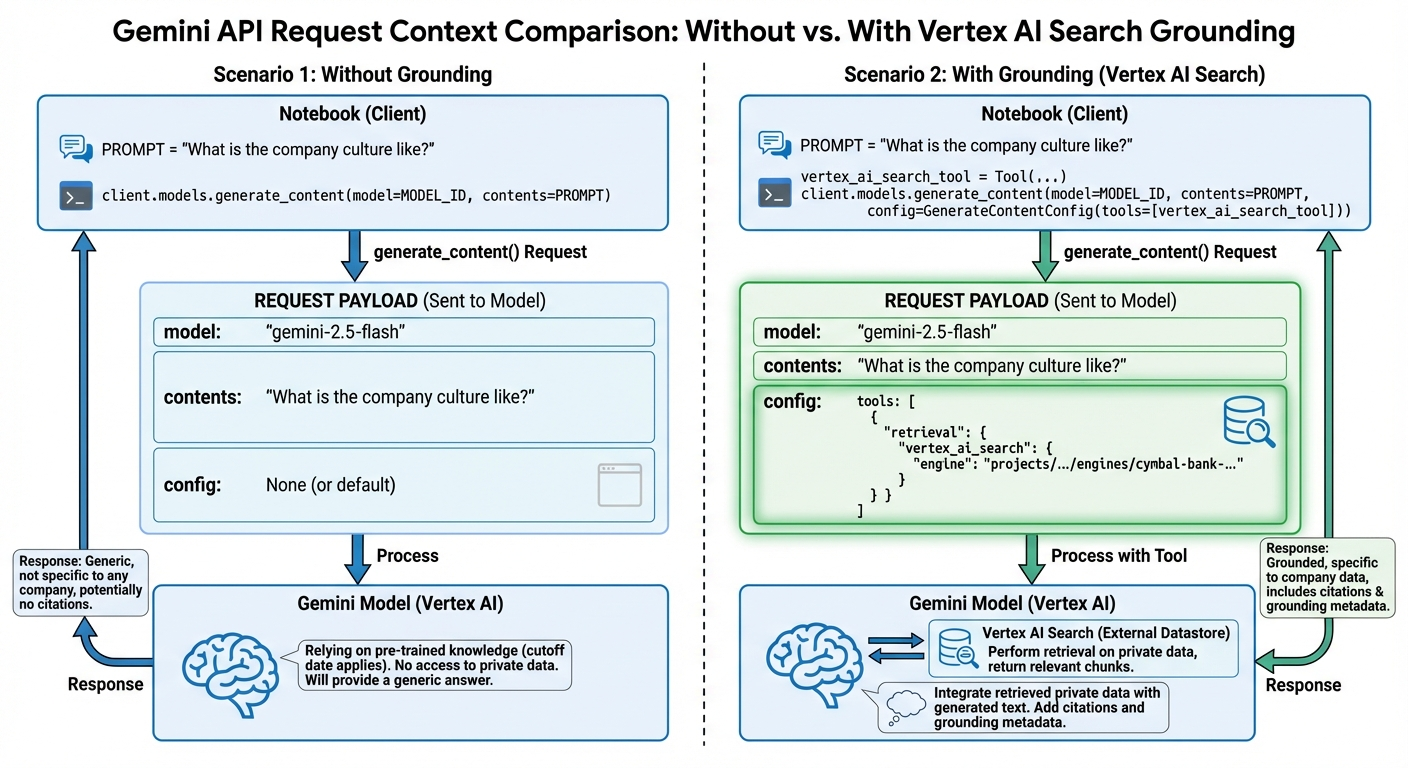

### Text generation without grounding

Make a prediction request to the LLM with no grounding:

In [ ]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents=PROMPT,
)

display(Markdown(response.text))

That's an excellent and very important question! However, I can't tell you what "the" company culture is like because it varies *dramatically* from one company to another.

To give you a helpful answer, I need to know **which specific company you're asking about.**

**What "Company Culture" Generally Refers To:**

Company culture is the shared values, beliefs, practices, and attitudes that characterize an organization and guide its members' behavior. It's often described as "how things are done around here."

**Key Aspects of Company Culture to Consider:**

When people ask about company culture, they're often trying to understand things like:

1.  **Core Values & Mission:**
    *   What does the company stand for? (e.g., innovation, customer-centricity, social impact, ethical practices, efficiency, growth at all costs)
    *   Is there a clear mission that employees believe in?

2.  **Work Environment & Pace:**
    *   **Fast-paced vs. Relaxed:** Is it a high-pressure, deadline-driven environment, or more laid-back with a focus on long-term projects?
    *   **Structured vs. Autonomous:** How much freedom do employees have to make decisions and manage their own work?
    *   **Competitive vs. Collaborative:** Is individual achievement prioritized, or is teamwork and mutual support emphasized?
    *   **Formal vs. Informal:** What's the dress code, communication style, and general atmosphere?

3.  **Communication & Collaboration:**
    *   **Openness & Transparency:** How much information is shared from leadership to employees?
    *   **Feedback Culture:** Is feedback encouraged? Is it constructive, or more critical?
    *   **Hierarchy:** Is it a flat organization with direct access to leaders, or a more traditional, layered structure?
    *   **Teamwork:** How often do teams collaborate? Are cross-functional teams common?

4.  **Leadership & Management Style:**
    *   **Empowering vs. Micromanaging:** Do leaders trust employees to do their jobs, or do they oversee every detail?
    *   **Supportive vs. Demanding:** Do managers act as mentors and advocates, or are they solely focused on output?
    *   **Accessible:** Are leaders approachable and willing to listen?

5.  **Growth & Development:**
    *   **Learning Opportunities:** Are there resources for professional development, training, and upskilling?
    *   **Career Paths:** Is there a clear path for advancement, or is it more ambiguous?
    *   **Innovation & Experimentation:** Is it safe to try new things and fail, or is risk-aversion prevalent?

6.  **Work-Life Balance & Perks:**
    *   **Hours:** Are long hours expected? Is overtime common?
    *   **Flexibility:** Are remote work, flexible hours, or unlimited PTO options available and genuinely encouraged?
    *   **Benefits & Perks:** (beyond standard compensation) E.g., gym memberships, free food, social events, mental health support.

7.  **Diversity, Equity, & Inclusion (DEI):**
    *   Is there a genuine commitment to creating a diverse workforce and an inclusive environment where everyone feels they belong?
    *   Are different perspectives valued?

8.  **Social & Team Dynamics:**
    *   Are there regular team-building activities or social events?
    *   Do colleagues socialize outside of work?
    *   Is there a sense of community or camaraderie?

**How to Find Out a Company's Culture (if you don't have a specific one in mind for me to look up):**

*   **Company Website:** Look at their "About Us," "Careers," or "Our Values" pages.
*   **Employee Review Sites:** Glassdoor, Indeed, LinkedIn often have reviews from current and former employees. (Take these with a grain of salt, as they can sometimes be skewed, but look for recurring themes.)
*   **News Articles & Social Media:** How does the company present itself publicly?
*   **Networking:** Talk to people who currently work there or have worked there in the past.
*   **During the Interview Process:** Pay attention to how people interact, ask specific questions about team dynamics, work-life balance, and decision-making processes.

**If you tell me the name of a specific company, I can try to find publicly available information and provide a summary of what's commonly reported about its culture.**

### Text generation grounded in Vertex AI Search results

Now we can add the `tools` keyword arg with a grounding tool of `grounding.VertexAISearch()` to instruct the LLM to first perform a search within your search app, then construct an answer based on the relevant documents:

In [ ]:
vertex_ai_search_tool = Tool(
    retrieval=Retrieval(
        vertex_ai_search=VertexAISearch(engine=VERTEX_AI_SEARCH_ENGINE_NAME)
    )
)

response = client.models.generate_content(
    model=MODEL_ID,
    contents="What is the company culture like?",
    config=GenerateContentConfig(tools=[vertex_ai_search_tool]),
)

print_grounding_data(response)

Cymbal Bank maintains a company culture that is described as fast-paced and results-oriented, with a focus on continuous improvement and innovation [1]. The organization places high value on collaboration, communication, and teamwork [1].

Key elements of Cymbal Bank's culture include:
*   **Open-mindedness** The company encourages employees to be receptive to learning about various cultures and perspectives, and to be open to adjusting their own views when appropriate, while consistently showing respect for others [2].
*   **Respect** There is a strong emphasis on respecting diverse cultures, religions, sexual orientations, and opinions, even in situations of disagreement [2].
*   **Inclusivity** Cymbal Bank is committed to ensuring that all individuals feel welcomed and included, regardless of their background or identity, and that everyone has an equal chance to participate and contribute [2].
*   **Diversity** Diversity is seen as a strength, with the company embracing different perspectives and experiences to foster an innovative and successful work environment, and encouraging individuals to challenge their own biases [2].
*   **Authenticity** Employees are encouraged to be genuine, honest about their beliefs, and comfortable and proud of their personal identity [2].

Furthermore, Cymbal Bank advises its employees to be mindful of their own biases, be receptive to feedback, be prepared for change, and exercise patience to cultivate trust and understanding within their diverse environment [2].

----
## Grounding Sources
### Grounding Chunks
1. [Cymbal Bank New Employee Guide](https://storage.googleapis.com/cloud-samples-data/gen-app-builder/search/cymbal-bank-employee/Cymbal%20Bank%20New%20Employee%20Guide.pdf)
6. Beyond your first year
After your first year at Cymbal Bank, you will have the opportunity to continue to grow and develop. You will have
the opportunity to take on new challenges and to take on new roles. You will also have the opportunity to learn
from your colleagues and to mentor them. 7. Resources
If you have any questions or concerns, please do not hesitate to reach out to your manager, HR department, or
team members. We are here to help you succeed. 8. Welcome to the team! We are excited to have you on our team and we look forward to working with you. Tools to get familiar with Cymbal Drive: Our internal communication tool. Cymbal Expense: Our expense tracking tool. Cymbal Fly: Our travel booking tool. Cymbal Stay: Our hotel booking tool. Cymbal Work: Our project management tool. Company culture
Cymbal Bank is a fast-paced, results-oriented company. We are always looking for ways to improve and innovate. We value collaboration, communication, and teamwork. 
...
Cymbal Bank New Employe Guide Updated August 11, 2023
Authored by Lewis Cymbal, CEO 1. Welcome to Cymbal Bank
Congratulations on joining Cymbal Bank! We are excited to have you on our team. 2. Your first day
Your first day at Cymbal Bank will be a busy one. You will meet with your manager, HR department, and team
members. You will also be given a tour of the office and introduced to your new colleagues. 3. Your first week
In your first week at Cymbal Bank, you will be given a lot of information to take in. You will learn about the company
culture, the products and services that we offer, and the expectations that we have for our employees. You will
also be given a lot of paperwork to fill out. 4. Your first month
In your first month at Cymbal Bank, you will start to get into the swing of things. You will start to learn your job and
the responsibilities that come with it. You will also start to build relationships with your colleagues. 5. Your first year
In your first year at Cymbal Bank, you will continue to learn and grow. You will start to take on more responsibility
and you will start to make a real impact on the company. You will also start to build a network of colleagues and
mentors. 

2. [Cymbal Bank Company Culture](https://storage.googleapis.com/cloud-samples-data/gen-app-builder/search/cymbal-bank-employee/Cymbal%20Bank%20Company%20Culture.pdf)
Cymbal Bank Company Culture Updated August 11, 2023
Authored by Lewis Cymbal, CEO 1. Be open-minded
One of the most important things you can do to be a productive member of an inclusive and diverse workforce is
to be open-minded. This means being willing to learn about different cultures and perspectives, and being willing
to change your own views when necessary. It also means being respectful of others, even if you disagree with
them. 2. Be respectful
Respect is essential for any productive workplace, but it is especially important in an inclusive and diverse
workforce. This means being respectful of other people's cultures, religions, and sexual orientations. It also means
being respectful of other people's opinions, even if you disagree with them. 3. Be inclusive
Inclusion is another important part of being a productive member of an inclusive and diverse workforce. This
means making sure that everyone feels welcome and included, regardless of their background or identity. It also
means making sure that everyone has an equal opportunity to participate and contribute. 4. Be diverse
Diversity is a strength, not a weakness. This means embracing different perspectives and experiences, and using
them to create a more innovative and successful workplace. It also means being willing to challenge your own
biases and assumptions. 
...
Celebrate the diversity of your workplace and
the contributions of all employees. 
...
5. Be yourself
Finally, it is important to be yourself in an inclusive and diverse workforce. This means being honest about who you
are and what you believe in. It also means being comfortable with your own identity and being proud of who you are. Following these tips will help you to be a productive member of an inclusive and diverse workforce. By being
open-minded, respectful, inclusive, diverse, and yourself, you can help to create a more positive and productive
workplace for everyone. Here are some additional tips for working in an inclusive and diverse environment: Be aware of your own biases. We all have biases, whether we are aware of them or not. It is important to be
aware of your own biases so that you can work to overcome them. Be open to feedback. If you are working in an inclusive and diverse environment, it is important to be open
to feedback. This will help you to learn and grow. Be willing to change. Change is inevitable, especially in an inclusive and diverse environment. Be willing to
change your own views and behaviors when necessary. Be patient. It takes time to build trust and understanding in an inclusive and diverse environment. Be
patient with yourself and with others. Celebrate diversity. Diversity is a strength, not a weakness. 


**Retrieval Queries:** ['company culture', 'what company are you referring to']


Note that the response without grounding doesn't have any context about what company we are asking about. Whereas the response that was grounded in Vertex AI Search results contains information from the documents provided, along with citations of the information.

<div class="alert alert-block alert-warning">
<b>⚠️ Important notes:</b><br>
<br>
<b>If you get an error when running the previous cell:</b><br>
&nbsp;&nbsp;&nbsp;&nbsp;In order for this sample notebook to work with data store in Vertex AI Search,<br>
&nbsp;&nbsp;&nbsp;&nbsp;you'll need to create a <a href="https://cloud.google.com/generative-ai-app-builder/docs/try-enterprise-search#create_a_data_store">data store</a> <b>and</b> a <a href="https://cloud.google.com/generative-ai-app-builder/docs/try-enterprise-search#create_a_search_app">search app</a> associated with it in Vertex AI Search.<br>
&nbsp;&nbsp;&nbsp;&nbsp;If you only create a data store, the previous request will return errors when making queries against the data store.
<br><br>
<b>If you get an empty response when running the previous cell:</b><br>
&nbsp;&nbsp;&nbsp;&nbsp;You will need to wait for data ingestion to finish before using a data store with grounding.<br>
&nbsp;&nbsp;&nbsp;&nbsp;For more information, see <a href="https://cloud.google.com/generative-ai-app-builder/docs/create-data-store-es">create a data store</a>.
</div>
</div>

## Example: Grounded chat responses

You can also use grounding when using chat conversations in Vertex AI. In this example, you'll compare LLM responses with no grounding with responses that are grounded in the results of a Google Search and a data store in Vertex AI Search.

In [ ]:
PROMPT = "What are managed datasets in Vertex AI?"
PROMPT_FOLLOWUP = "What types of data can I use?"

### Chat session grounded in Google Search results

Now you can add the `tools` keyword arg with a Tool of `GoogleSearch` to instruct the chat model to first perform a Google Search with the prompt, then construct an answer based on the web search results:

In [ ]:
chat = client.chats.create(
    model=MODEL_ID,
    config=GenerateContentConfig(tools=[Tool(google_search=GoogleSearch())]),
)

display(Markdown("## Prompt"))
display(Markdown(f"> {PROMPT}"))
response = chat.send_message(PROMPT)
print_grounding_data(response)

display(Markdown("---\n"))

display(Markdown("## Follow-up Prompt"))
display(Markdown(f"> {PROMPT_FOLLOWUP}"))
response = chat.send_message(PROMPT_FOLLOWUP)
print_grounding_data(response)

## Prompt

> What are managed datasets in Vertex AI?

Managed datasets in Vertex AI are centralized repositories for machine learning data within the Google Cloud Vertex AI framework [1][2]. They offer a structured approach to managing, preparing, and accessing data for training and serving machine learning models [2].

Key aspects and benefits of managed datasets in Vertex AI include:
*   **Centralized Management** They provide a single source of truth for your machine learning data, stored in a central location within Vertex AI [1][2]. This simplifies dataset organization, access, and version control [2][3].
*   **Support for AutoML and Custom Models** Managed datasets are required for AutoML training and are optional but highly beneficial for custom model training within Vertex AI [1][4].
*   **Data Preparation and Preprocessing** They streamline data preparation by supporting tasks such as data cleansing, transformation, encoding, and automated preprocessing like normalization and feature engineering [2][3]. This reduces manual effort and accelerates the development of ML models [2][3].
*   **Labeling and Annotation** Managed datasets allow for easy creation of labels and multiple annotation sets, including tasks for human labeling using integrated tools [1][3][5].
*   **Data Splitting** Vertex AI can automatically split datasets into training, validation, and testing sets, which is crucial for model development and evaluation [1][5].
*   **Lineage Tracking and Governance** They enable tracking of data lineage to models, which is important for governance and iterative development. This includes versioning, access controls, and integrations for monitoring metrics [1][3][5].
*   **Model Performance Comparison** Users can compare AI model performance by training multiple models using the same managed dataset [1][3][5].
*   **Data Statistics and Visualizations** Managed datasets can generate statistical data and visualizations to help understand the dataset's characteristics [1][5].
*   **Supported Data Types** Vertex AI supports managed datasets for various data types, including image, tabular, text, and video [4][6].

Managed datasets can be created using the Google Cloud Console or the Vertex AI APIs, and the preparation process varies based on the data type and the intended operations [1][4]. Data can be imported from local files, Cloud Storage buckets, or BigQuery tables [2]. For tabular datasets, a data schema can be defined to help Vertex AI understand the data structure [2].

----
## Grounding Sources
### Grounding Chunks
1. [medium.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQFg4tnbkZLyADrQb3mrb7BZCozm54q9evyP0CobdXrgZbv6aN4XWGVaW-YWrAIMx02AqmMvKn-iDQYwGJXVrFwXzS2ix3sD-WQQBQCRTUJYiyWTCq6LhDEnioshMvGg_NUpAFlV10QSS8XwhR1sJ1IQCXiOAKC5Pzr0hmTIT-28Np9FL6Sw1RoWT5FPA1EgF7klizKmfEQBwjMpIPGaXPZk-jNBPI7iW0JttQ==)
2. [promevo.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQGExRLP42Eog7PB2Ediax35Il0sxFBjJPeYfwCLzcNVVL7Y8NoETdOJo0WFW0jorlMpwyZ5N9h2-H3uLLaC0YoueTxBKWtdR8ePJybfOy_JVKyLET8YNznFFdTrl81e0pdspWjeFTh9hSuNeaAJy_IbYBdq)
3. [promevo.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQGu-ygeQxaAwZzvt490-TclKY-P2EwR8VXSIHHOaNqKkyt1B4Nm45lUxl-1bhvwV8u4-RRCH2Uo7fuwXF8tTDewVnHBRwGUyO_XVuc5r__qS0yfHeydXVTIkhcG0hDejyx_7dIhFNBCpWhfqQm_qILP)
4. [google.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQG5EFyBbF85kDYidFeEPfoSoeTxJe8iT_Jb2dB8f-DO9tLcqGAkU_J5RHW9wDk-aA3s2vplHTTHnfEMrOe4HL17sQ4m4IFE1EeuQjJKQ6gi4opWOKLbtSDbLzhh4AnquCiBpJRcVb8VA3ZFThyeIuBwVuNZYA==)
5. [google.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQFYHgtVhdDqTuOLqwjdf-dp23cUfWwEkeUWvPCEjtyGWjHxziIT_tOudVpP_rSV8i4JM8vMs74XOTjiUnoxnLatBYJsNylDfJ8KRkz7pvO7QCaGoDT6cnNKIVmks--MUGGExWwF0bBtZLQtIga6BOBaQO8sX1Y0-Ra1yuZViyNcPqB6)
6. [cloud-ace.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQFS0xNmyV8xXhM1EJef8mXKmEC4SQ-TLdAREBGKhVl5kIGYoeuNmuIFO65f_VmkhMVi6JnF9UE7T2E5Hrb6PXo_Hy4uujPEAEc-VGAwZxaunvPQ3Ne9WdWxzwWQb4qHzNPN5p5ILqQk5WcONTtbkyQt8aEp7GLKBSSGdj3YavXjHpm2)

**Web Search Queries:** ['Vertex AI managed dataset features', 'managed datasets in Vertex AI', 'benefits of managed datasets Vertex AI']

**Search Entry Point:**
<style>
.container {
  align-items: center;
  border-radius: 8px;
  display: flex;
  font-family: Google Sans, Roboto, sans-serif;
  font-size: 14px;
  line-height: 20px;
  padding: 8px 12px;
}
.chip {
  display: inline-block;
  border: solid 1px;
  border-radius: 16px;
  min-width: 14px;
  padding: 5px 16px;
  text-align: center;
  user-select: none;
  margin: 0 8px;
  -webkit-tap-highlight-color: transparent;
}
.carousel {
  overflow: auto;
  scrollbar-width: none;
  white-space: nowrap;
  margin-right: -12px;
}
.headline {
  display: flex;
  margin-right: 4px;
}
.gradient-container {
  position: relative;
}
.gradient {
  position: absolute;
  transform: translate(3px, -9px);
  height: 36px;
  width: 9px;
}
@media (prefers-color-scheme: light) {
  .container {
    background-color: #fafafa;
    box-shadow: 0 0 0 1px #0000000f;
  }
  .headline-label {
    color: #1f1f1f;
  }
  .chip {
    background-color: #ffffff;
    border-color: #d2d2d2;
    color: #5e5e5e;
    text-decoration: none;
  }
  .chip:hover {
    background-color: #f2f2f2;
  }
  .chip:focus {
    background-color: #f2f2f2;
  }
  .chip:active {
    background-color: #d8d8d8;
    border-color: #b6b6b6;
  }
  .logo-dark {
    display: none;
  }
  .gradient {
    background: linear-gradient(90deg, #fafafa 15%, #fafafa00 100%);
  }
}
@media (prefers-color-scheme: dark) {
  .container {
    background-color: #1f1f1f;
    box-shadow: 0 0 0 1px #ffffff26;
  }
  .headline-label {
    color: #fff;
  }
  .chip {
    background-color: #2c2c2c;
    border-color: #3c4043;
    color: #fff;
    text-decoration: none;
  }
  .chip:hover {
    background-color: #353536;
  }
  .chip:focus {
    background-color: #353536;
  }
  .chip:active {
    background-color: #464849;
    border-color: #53575b;
  }
  .logo-light {
    display: none;
  }
  .gradient {
    background: linear-gradient(90deg, #1f1f1f 15%, #1f1f1f00 100%);
  }
}
</style>
<div class="container">
  <div class="headline">
    <svg class="logo-light" width="18" height="18" viewBox="9 9 35 35" fill="none" xmlns="http://www.w3.org/2000/svg">
      <path fill-rule="evenodd" clip-rule="evenodd" d="M42.8622 27.0064C42.8622 25.7839 42.7525 24.6084 42.5487 23.4799H26.3109V30.1568H35.5897C35.1821 32.3041 33.9596 34.1222 32.1258 35.3448V39.6864H37.7213C40.9814 36.677 42.8622 32.2571 42.8622 27.0064V27.0064Z" fill="#4285F4"/>
      <path fill-rule="evenodd" clip-rule="evenodd" d="M26.3109 43.8555C30.9659 43.8555 34.8687 42.3195 37.7213 39.6863L32.1258 35.3447C30.5898 36.3792 28.6306 37.0061 26.3109 37.0061C21.8282 37.0061 18.0195 33.9811 16.6559 29.906H10.9194V34.3573C13.7563 39.9841 19.5712 43.8555 26.3109 43.8555V43.8555Z" fill="#34A853"/>
      <path fill-rule="evenodd" clip-rule="evenodd" d="M16.6559 29.8904C16.3111 28.8559 16.1074 27.7588 16.1074 26.6146C16.1074 25.4704 16.3111 24.3733 16.6559 23.3388V18.8875H10.9194C9.74388 21.2072 9.06992 23.8247 9.06992 26.6146C9.06992 29.4045 9.74388 32.022 10.9194 34.3417L15.3864 30.8621L16.6559 29.8904V29.8904Z" fill="#FBBC05"/>
      <path fill-rule="evenodd" clip-rule="evenodd" d="M26.3109 16.2386C28.85 16.2386 31.107 17.1164 32.9095 18.8091L37.8466 13.8719C34.853 11.082 30.9659 9.3736 26.3109 9.3736C19.5712 9.3736 13.7563 13.245 10.9194 18.8875L16.6559 23.3388C18.0195 19.2636 21.8282 16.2386 26.3109 16.2386V16.2386Z" fill="#EA4335"/>
    </svg>
    <svg class="logo-dark" width="18" height="18" viewBox="0 0 48 48" xmlns="http://www.w3.org/2000/svg">
      <circle cx="24" cy="23" fill="#FFF" r="22"/>
      <path d="M33.76 34.26c2.75-2.56 4.49-6.37 4.49-11.26 0-.89-.08-1.84-.29-3H24.01v5.99h8.03c-.4 2.02-1.5 3.56-3.07 4.56v.75l3.91 2.97h.88z" fill="#4285F4"/>
      <path d="M15.58 25.77A8.845 8.845 0 0 0 24 31.86c1.92 0 3.62-.46 4.97-1.31l4.79 3.71C31.14 36.7 27.65 38 24 38c-5.93 0-11.01-3.4-13.45-8.36l.17-1.01 4.06-2.85h.8z" fill="#34A853"/>
      <path d="M15.59 20.21a8.864 8.864 0 0 0 0 5.58l-5.03 3.86c-.98-2-1.53-4.25-1.53-6.64 0-2.39.55-4.64 1.53-6.64l1-.22 3.81 2.98.22 1.08z" fill="#FBBC05"/>
      <path d="M24 14.14c2.11 0 4.02.75 5.52 1.98l4.36-4.36C31.22 9.43 27.81 8 24 8c-5.93 0-11.01 3.4-13.45 8.36l5.03 3.85A8.86 8.86 0 0 1 24 14.14z" fill="#EA4335"/>
    </svg>
    <div class="gradient-container"><div class="gradient"></div></div>
  </div>
  <div class="carousel">
    <a class="chip" href="https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQG-psEGA3AAvMAy-n1mDJTD7PkcXgk-m2jCclNZ5dyS7q__ajjm9-JyOO3FP6xGCYE3Oa5m5YWmzp2PKz_3wbTTToGETokwfqBecXyMjzjzDrVGFCtmhDydlqQHZ74dAD9VVDX1jveaQnoMnc1qcVHZbzE7qY-KMlzB_gMYYsJE7uA69rGG8wFy-AldCl3rT0rqdRS3jdUPxA35ayjKaL5s6aNR4cg=">Vertex AI managed dataset features</a>
    <a class="chip" href="https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQG99yxYWEyx_VyIx34Y4Toqrz4Eb5ff3e6f_fi-lJYMzQ2AZGSMOBo7iZ60jktcfyefGYe0PgPiGzwkIUwvKwuPmKVN-3fSHTPVx7KuOs8pj0aQeUdZpeJlqEAZuvYd3o2BkyOxqILZY4G_Xaz2Vu32mt40WC4Ns94ErPRk0kabssEZEs8U8pWgL2QgQq0lQSIYLTqyJwbWhOp33nFIN9R_">managed datasets in Vertex AI</a>
    <a class="chip" href="https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHvGEsK_pmAHfS4l6chFegl8kTCidwHOVzorKZurIjPZIYuwvuUYjiglGYEcB4Kg-8EAO548qAYUvYXSdLmURE5nIQQ4cWozpIHa1bsu6bOnTwqhz9VJwW0gXH9MQHmyMoXYV3zRKuXmuD5lNXGOrR7U4shJz4PAKz0v1Bg-c0T78Sb_g2cnBfrteaIAQ6fqvGGo5ONcmcLGAoMlOgXrSI9UeLyZM-CWb5Y">benefits of managed datasets Vertex AI</a>
  </div>
</div>



---


## Follow-up Prompt

> What types of data can I use?

Vertex AI managed datasets support a variety of data types, catering to different machine learning tasks. The primary data types you can use include:

*   **Tabular Datasets:** These consist of structured data organized in rows and columns, typically in formats like CSV or JSON. They are commonly used for tasks such as classification, regression, and forecasting. For tabular data, you can define a schema to help Vertex AI understand the data structure and perform automated preprocessing. Vertex AI can automatically split tabular datasets into training, validation, and testing sets, or you can specify a manual split. [1][2]
*   **Image Datasets:** These datasets contain images and are used for computer vision tasks such as image classification, object detection, and image segmentation. Supported image formats for training include JPEG, GIF, PNG, BMP, and ICO. [1][2]
*   **Text Datasets:** Comprising written text, these datasets are utilized for natural language processing (NLP) tasks like text classification, sentiment analysis, and entity extraction. [1]
*   **Video Datasets:** These contain video files and are used for tasks such as video classification, object tracking, and action recognition. [1]

For all these data types, Vertex AI passes the data to your training application in specific formats. For image, text, and video datasets, data is typically passed in JSON Lines format, while tabular data can be passed in CSV format or as a URI to a BigQuery table or view. [3]

----
## Grounding Sources
### Grounding Chunks
1. [promevo.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHOjc6CDCC5rRr0-LyBK3CU_7oWqgkiedyZw-nZcJ6FILAAWz54qG2EtxN_68UOs7wfigx4kvcZKeYW9U3fKv-iFHMv2lbn4Wi2SXcfwE6D3RYNBiMwomH7Tv7RlvuvBg2udNjsLdhmCsDXwqGw1q9Ko6oa)
2. [medium.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQG6vnam3n2FjtTvncf-9X2NjRGZS_mz6QK-4JGGi_pmbllCAMBXhExUEoe598u4qTv1-OBubr9jSd9dTycOpnAfLyHCvcgujsro7WrvepwgOQSawuJhoSYwqWeEj3bceEdiqZsVi8072OcwL55smvHKMBqfFuE7acLC76JmvqscVzYAqJCI4IEkwRexYYh7TvOwnGuG2p322lsvCOOB_bd4VTVOJSQuMJLehQ==)
3. [google.com](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQGoxkGuaO4V7aYLAd4GLkywSi8QWcXIV5uQRKf_D_Uxrb5yo0hwnQATi542cXAc3Zeig2EeqGiPkavtrUBIRhkw7tAMd_Byl5iMsEt0O9jeCf321nK37T8u8r3RI8uUmpPVZK4FOSrV-UqmGh67Ww36OJXM7GnOkS4SlZWmGMja6LW-)

**Web Search Queries:** ['Vertex AI managed datasets supported data types']

**Search Entry Point:**
<style>
.container {
  align-items: center;
  border-radius: 8px;
  display: flex;
  font-family: Google Sans, Roboto, sans-serif;
  font-size: 14px;
  line-height: 20px;
  padding: 8px 12px;
}
.chip {
  display: inline-block;
  border: solid 1px;
  border-radius: 16px;
  min-width: 14px;
  padding: 5px 16px;
  text-align: center;
  user-select: none;
  margin: 0 8px;
  -webkit-tap-highlight-color: transparent;
}
.carousel {
  overflow: auto;
  scrollbar-width: none;
  white-space: nowrap;
  margin-right: -12px;
}
.headline {
  display: flex;
  margin-right: 4px;
}
.gradient-container {
  position: relative;
}
.gradient {
  position: absolute;
  transform: translate(3px, -9px);
  height: 36px;
  width: 9px;
}
@media (prefers-color-scheme: light) {
  .container {
    background-color: #fafafa;
    box-shadow: 0 0 0 1px #0000000f;
  }
  .headline-label {
    color: #1f1f1f;
  }
  .chip {
    background-color: #ffffff;
    border-color: #d2d2d2;
    color: #5e5e5e;
    text-decoration: none;
  }
  .chip:hover {
    background-color: #f2f2f2;
  }
  .chip:focus {
    background-color: #f2f2f2;
  }
  .chip:active {
    background-color: #d8d8d8;
    border-color: #b6b6b6;
  }
  .logo-dark {
    display: none;
  }
  .gradient {
    background: linear-gradient(90deg, #fafafa 15%, #fafafa00 100%);
  }
}
@media (prefers-color-scheme: dark) {
  .container {
    background-color: #1f1f1f;
    box-shadow: 0 0 0 1px #ffffff26;
  }
  .headline-label {
    color: #fff;
  }
  .chip {
    background-color: #2c2c2c;
    border-color: #3c4043;
    color: #fff;
    text-decoration: none;
  }
  .chip:hover {
    background-color: #353536;
  }
  .chip:focus {
    background-color: #353536;
  }
  .chip:active {
    background-color: #464849;
    border-color: #53575b;
  }
  .logo-light {
    display: none;
  }
  .gradient {
    background: linear-gradient(90deg, #1f1f1f 15%, #1f1f1f00 100%);
  }
}
</style>
<div class="container">
  <div class="headline">
    <svg class="logo-light" width="18" height="18" viewBox="9 9 35 35" fill="none" xmlns="http://www.w3.org/2000/svg">
      <path fill-rule="evenodd" clip-rule="evenodd" d="M42.8622 27.0064C42.8622 25.7839 42.7525 24.6084 42.5487 23.4799H26.3109V30.1568H35.5897C35.1821 32.3041 33.9596 34.1222 32.1258 35.3448V39.6864H37.7213C40.9814 36.677 42.8622 32.2571 42.8622 27.0064V27.0064Z" fill="#4285F4"/>
      <path fill-rule="evenodd" clip-rule="evenodd" d="M26.3109 43.8555C30.9659 43.8555 34.8687 42.3195 37.7213 39.6863L32.1258 35.3447C30.5898 36.3792 28.6306 37.0061 26.3109 37.0061C21.8282 37.0061 18.0195 33.9811 16.6559 29.906H10.9194V34.3573C13.7563 39.9841 19.5712 43.8555 26.3109 43.8555V43.8555Z" fill="#34A853"/>
      <path fill-rule="evenodd" clip-rule="evenodd" d="M16.6559 29.8904C16.3111 28.8559 16.1074 27.7588 16.1074 26.6146C16.1074 25.4704 16.3111 24.3733 16.6559 23.3388V18.8875H10.9194C9.74388 21.2072 9.06992 23.8247 9.06992 26.6146C9.06992 29.4045 9.74388 32.022 10.9194 34.3417L15.3864 30.8621L16.6559 29.8904V29.8904Z" fill="#FBBC05"/>
      <path fill-rule="evenodd" clip-rule="evenodd" d="M26.3109 16.2386C28.85 16.2386 31.107 17.1164 32.9095 18.8091L37.8466 13.8719C34.853 11.082 30.9659 9.3736 26.3109 9.3736C19.5712 9.3736 13.7563 13.245 10.9194 18.8875L16.6559 23.3388C18.0195 19.2636 21.8282 16.2386 26.3109 16.2386V16.2386Z" fill="#EA4335"/>
    </svg>
    <svg class="logo-dark" width="18" height="18" viewBox="0 0 48 48" xmlns="http://www.w3.org/2000/svg">
      <circle cx="24" cy="23" fill="#FFF" r="22"/>
      <path d="M33.76 34.26c2.75-2.56 4.49-6.37 4.49-11.26 0-.89-.08-1.84-.29-3H24.01v5.99h8.03c-.4 2.02-1.5 3.56-3.07 4.56v.75l3.91 2.97h.88z" fill="#4285F4"/>
      <path d="M15.58 25.77A8.845 8.845 0 0 0 24 31.86c1.92 0 3.62-.46 4.97-1.31l4.79 3.71C31.14 36.7 27.65 38 24 38c-5.93 0-11.01-3.4-13.45-8.36l.17-1.01 4.06-2.85h.8z" fill="#34A853"/>
      <path d="M15.59 20.21a8.864 8.864 0 0 0 0 5.58l-5.03 3.86c-.98-2-1.53-4.25-1.53-6.64 0-2.39.55-4.64 1.53-6.64l1-.22 3.81 2.98.22 1.08z" fill="#FBBC05"/>
      <path d="M24 14.14c2.11 0 4.02.75 5.52 1.98l4.36-4.36C31.22 9.43 27.81 8 24 8c-5.93 0-11.01 3.4-13.45 8.36l5.03 3.85A8.86 8.86 0 0 1 24 14.14z" fill="#EA4335"/>
    </svg>
    <div class="gradient-container"><div class="gradient"></div></div>
  </div>
  <div class="carousel">
    <a class="chip" href="https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQEp96256aOHfbCFpQHS4VORAkDBPElxN1WW2F0BbtiOLABESx6dLa0NCPdipfC9vmQjROEvurMqfO9lD-S7qY1-rhuhjN6N1oI7uEVSh1H4fqI3V47PfYyuk2zRKmJiren4lPuLjTbhIWPnrjkY9m8sdJJvDFVoUNpD_l_SyZlZImaGHfUeAFlDEuT6FHnhpJlt1ODMMFape5JiYbnqCXipMTUK8stru4rpn2GUwUw7LGl-">Vertex AI managed datasets supported data types</a>
  </div>
</div>



### Chat session grounded in Vertex AI Search results

Now we can add the `tools` keyword arg with a grounding tool of `VertexAISearch` to instruct the chat session to first perform a search within your custom search app, then construct an answer based on the relevant documents:

In [ ]:
PROMPT = "How do I book business travel?"
PROMPT_FOLLOWUP = "Give me more details."

In [ ]:
chat = client.chats.create(
    model=MODEL_ID,
    config=GenerateContentConfig(
        tools=[
            Tool(
                retrieval=Retrieval(
                    vertex_ai_search=VertexAISearch(engine=VERTEX_AI_SEARCH_ENGINE_NAME)
                )
            )
        ]
    ),
)

display(Markdown("## Prompt"))
display(Markdown(f"> {PROMPT}"))
response = chat.send_message(PROMPT)
print_grounding_data(response)

display(Markdown("---\n"))

display(Markdown("## Follow-up Prompt"))
display(Markdown(f"> {PROMPT_FOLLOWUP}"))
response = chat.send_message(PROMPT_FOLLOWUP)
print_grounding_data(response)

## Prompt

> How do I book business travel?

To book business travel, you typically follow a structured process that can involve various tools and approaches depending on whether you are an individual, part of a small business, or an employee of a larger corporation.

**General Steps to Book Business Travel:**

1.  **Understand Company Policy (if applicable):** If you are traveling for a company, the first step is to familiarize yourself with your organization's business travel policy. This policy will outline approved booking methods, budget constraints, preferred vendors (airlines, hotels, car rentals), expense reporting procedures, and any pre-approval requirements.

2.  **Determine Travel Needs:**
    *   **Destination and Dates:** Pinpoint the exact location and the departure and return dates.
    *   **Purpose of Travel:** Is it for a client meeting, conference, project work, or internal gathering? This can influence budget and accommodation choices.
    *   **Attendees:** Is it just you, or are multiple team members traveling?
    *   **Transportation:** Will you need flights, trains, rental cars, or local transportation?
    *   **Accommodation:** What type of hotel or lodging is required?
    *   **Other Needs:** Consider visas, meeting room bookings, or specific equipment.

3.  **Choose a Booking Method:**

    *   **Corporate Travel Agencies (CTAs) or Travel Management Companies (TMCs):** Many companies, especially larger ones, use CTAs or TMCs. These agencies specialize in business travel, often negotiate corporate rates, and provide services like itinerary management, 24/7 support, and expense integration. They can save time and often offer better deals.
    *   **Online Booking Tools (OBTs):** Many businesses use specialized online platforms designed for corporate travel. These tools allow employees to book flights, hotels, and rental cars within company policy guidelines, often offering a range of options and automating approval workflows.
    *   **Direct Booking:** For smaller businesses or individual entrepreneurs, booking directly with airlines, hotels, or car rental companies through their websites can be an option. This offers flexibility but might lack corporate discounts or centralized management.
    *   **Travel Aggregators/Online Travel Agencies (OTAs):** While more commonly used for leisure travel, some businesses might use popular OTAs for direct bookings, especially if there isn't a formal travel program in place.

4.  **Book Travel Components:**

    *   **Flights:** Book flights according to your itinerary and company policy, considering factors like preferred airlines, direct routes, and budget.
    *   **Accommodation:** Reserve a hotel or other lodging that meets the trip's requirements and adheres to budget guidelines.
    *   **Ground Transportation:** Arrange for rental cars, airport transfers, or public transport as needed.
    *   **Other Reservations:** Book meeting rooms, specific equipment, or other services in advance.

5.  **Obtain Approvals:** Ensure all necessary travel approvals are secured before finalizing bookings, as per company policy.

6.  **Manage Expenses:**
    *   **Track Spending:** Keep meticulous records of all business-related expenses, including receipts.
    *   **Submit Expense Reports:** Utilize your company's expense tracking system (e.g., Cymbal Expense, if your company uses it [1]) to submit expenses for reimbursement. This typically involves entering details about the trip, amounts spent, and attaching receipts [1].
    *   **Reimbursement:** Once approved, you will receive reimbursement for your expenses, often via direct deposit or check [1]. Some companies may also offer travel advances for upfront costs [1].

7.  **Follow Up:** After your trip, it's important to submit expenses promptly and keep your manager or HR department updated on your travel to ensure timely reimbursement [1].

----
## Grounding Sources
### Grounding Chunks
1. [Cymbal Bank Business Travel Guide](https://storage.googleapis.com/cloud-samples-data/gen-app-builder/search/cymbal-bank-employee/Cymbal%20Bank%20Business%20Travel%20Guide.pdf)
Cymbal Bank Business Travel Guide Updated August 11, 2023
Authored by Lewis Cymbal, Founder & CEO 1. Book your flight
To book your flight, you can use the company's travel booking tool, called "Cymbal Fly". To use Cymbal Fly, you will
need to create an account and log in. Once you are logged in, you can search for flights by destination, date, and
time. You can also filter your results by airline, price, and duration. Once you have found a flight that you are
interested in, you can book it by clicking on the "Book Now" button. 2. Book your hotel
To book your hotel, you can use the company's travel booking tool, called "Cymbal Stay". To use Cymbal Stay, you
will need to create an account and log in. Once you are logged in, you can search for hotels by destination, date,
and time. You can also filter your results by price, rating, and amenities. Once you have found a hotel that you are
interested in, you can book it by clicking on the "Book Now" button. 3. Book your rental car
To book your rental car, you can use the company's travel booking tool, called "Cymbal Drive". 
...
To use Cymbal Drive,
you will need to create an account and log in. Once you are logged in, you can search for rental cars by destination,
date, and time. You can also filter your results by price, size, and features. Once you have found a rental car that
you are interested in, you can book it by clicking on the "Book Now" button. 4. Submit your expenses
Once you have returned from your business trip, you will need to submit your expenses. To do this, you will need to
use the company's expense tracking tool, called "Cymbal Expense". To use Cymbal Expense, you will need to
create an account and log in. Once you are logged in, you can create a new expense report by clicking on the
"Create New Report" button. You will need to enter your name, date, and destination. You will also need to enter the
purpose of your trip, the amount of money that you spent, and the receipts for your expenses. Once you have
entered all of the necessary information, you can submit your expense report by clicking on the "Submit Report"
button. 5. Receive reimbursement
Once your expense report has been approved, you will receive reimbursement for your expenses. You can receive
reimbursement by direct deposit or by check. 
...
6. Request a travel advance
If you need to travel for work before you have been reimbursed for your expenses, you can request a travel
advance. To do this, you will need to contact your manager or HR department. They will be able to help you with
the process of requesting a travel advance. 7. Follow up on your travel
Once you have returned from your business trip, it is important to follow up on your travel. This includes submitting
your expenses, requesting a travel advance, and receiving reimbursement for your expenses. It is also important to
keep your manager or HR department updated on your travel. This will help to ensure that you are reimbursed for
your expenses in a timely manner. 


**Retrieval Queries:** ['how to book business travel', 'steps to book business travel', 'general methods for booking business travel', 'online booking tools for business travel', 'benefits of a business travel policy', 'corporate travel agencies for business travel', 'managing business travel expenses best practices', 'creating a business travel policy', 'corporate travel management companies', 'best practices for managing business travel expenses', 'general ways to book business travel', 'online business travel booking platforms', 'general methods for booking business travel', 'online travel booking platforms for businesses', 'best practices for managing business travel expenses', 'how to create a business travel policy', 'corporate travel agencies for small business', 'how do companies arrange business trips', 'general guide to booking business travel', 'common methods for corporate travel booking', 'business travel planning process']


---


## Follow-up Prompt

> Give me more details.

To provide more detailed guidance on booking business travel, let's expand on the key areas, including understanding company policies, choosing booking methods, and managing expenses.

### 1. Understanding Company Policies and Pre-approval

Before booking anything, thoroughly review your company's travel policy. This document is crucial as it outlines the rules and procedures you must follow. Key elements often found in a business travel policy include:

*   **Preferred Vendors:** Many companies have agreements with specific airlines, hotel chains, and car rental companies to secure corporate rates. Using these preferred vendors can be mandatory and often leads to cost savings for the company and sometimes perks for the traveler.
*   **Budget Limits:** Policies will specify spending caps for flights (e.g., economy class for domestic, business class for international over a certain flight duration), accommodation (per diem rates or maximum nightly rates), and sometimes meals.
*   **Booking Channels:** The policy will dictate how you are permitted to book your travel—whether through a designated online booking tool (OBT), a corporate travel agency (CTA), or if direct booking is allowed.
*   **Pre-approval Process:** For many trips, especially those exceeding a certain cost or duration, pre-approval from a manager or a specific department is required before any bookings can be finalized. This usually involves submitting a travel request form detailing the purpose, dates, destination, and estimated costs.
*   **Expense Categories and Reporting:** The policy defines what expenses are reimbursable (e.g., meals, ground transportation, internet, tips) and the maximum amounts for each. It will also detail the expense reporting timeline and the required documentation (receipts).
*   **Safety and Security:** Information regarding travel insurance, emergency contacts, and procedures for high-risk destinations might also be included.

### 2. Choosing a Booking Method

The method you use to book your business travel largely depends on your company's size and its established travel management program.

*   **Corporate Travel Agencies (CTAs) / Travel Management Companies (TMCs):**
    *   **Pros:** CTAs offer personalized service, 24/7 support (crucial for unexpected changes or emergencies), access to negotiated corporate rates, and streamlined billing. They can handle complex itineraries, group bookings, and provide detailed reporting for the company. They often integrate with expense management systems.
    *   **Cons:** Can sometimes be less flexible than direct booking for simple trips, and service fees may apply.
    *   **When to Use:** Ideal for larger companies, frequent business travelers, complex international trips, or when significant support and policy compliance are priorities.

*   **Online Booking Tools (OBTs):**
    *   **Pros:** OBTs provide a self-service platform where employees can book flights, hotels, and rental cars directly, often within pre-set policy parameters. They automate approval workflows, enforce budget limits, and integrate with expense systems. Examples include tools like "Cymbal Fly," "Cymbal Stay," and "Cymbal Drive" for booking flights, hotels, and rental cars, respectively, as mentioned in the Cymbal Bank guide [1].
    *   **Cons:** Less personalized support compared to a CTA, and can be frustrating if the tool is not intuitive or lacks sufficient options.
    *   **When to Use:** Common in mid-sized to large companies for empowering employees with self-service while maintaining policy compliance and cost control.

*   **Direct Booking (Airline, Hotel, Car Rental Websites):**
    *   **Pros:** Offers the most flexibility and direct access to loyalty programs and the widest range of options. Can be useful for very small businesses or individual entrepreneurs without a formal travel program.
    *   **Cons:** No corporate discounts unless you have direct agreements, lacks centralized reporting, requires manual expense tracking, and offers no consolidated support. Policy compliance can be difficult to enforce.
    *   **When to Use:** Suitable for very small businesses, freelancers, or when a company has no formal travel policy or tools.

*   **Travel Aggregators/Online Travel Agencies (OTAs - e.g., Expedia, Booking.com):**
    *   **Pros:** Offer a wide range of options and competitive pricing for leisure travel.
    *   **Cons:** Generally not recommended for business travel due to lack of corporate rates, limited ability to integrate with corporate expense systems, and challenges with policy enforcement.

### 3. Booking Specific Travel Components

*   **Flights:**
    *   **Considerations:** Cost, preferred airline, direct vs. connecting flights, layover times, flight duration, departure/arrival times that align with meeting schedules, and loyalty program benefits.
    *   **Booking Tips:** Book in advance for better rates. Be flexible with travel dates if possible. Review baggage allowances.

*   **Accommodation:**
    *   **Considerations:** Proximity to meetings/worksite, company-preferred hotels, safety, amenities (Wi-Fi, breakfast, gym), and loyalty programs.
    *   **Booking Tips:** Ensure the booking aligns with the nightly rate limit in your policy. Check cancellation policies.

*   **Ground Transportation:**
    *   **Considerations:** Rental car needs (size, fuel efficiency), airport transfers (taxis, ride-shares, public transport), and local transport options at your destination.
    *   **Booking Tips:** For rental cars, understand insurance options. Pre-book airport transfers to save time upon arrival.

### 4. Managing Expenses

Effective expense management is critical for timely reimbursement and accurate financial records.

*   **Track Spending Religiously:** Keep all receipts, both physical and digital. Many companies use digital expense tracking tools like "Cymbal Expense" [1][2].
*   **Categorize Expenses:** Clearly differentiate between travel, accommodation, meals, entertainment, and other business-related costs.
*   **Submit Expense Reports Promptly:** Adhere to your company's submission deadlines. Delays can lead to issues with reimbursement. The Cymbal Bank guide advises submitting expense reports once you return from your business trip [1].
*   **Required Information:** Expense reports typically require your name, date, destination, purpose of the trip, amount spent, and attached receipts [1].
*   **Travel Advances:** If you anticipate significant out-of-pocket expenses, inquire about a travel advance from your manager or HR department before your trip [1].

### 5. Post-Travel Procedures

*   **Submit Final Reports:** Complete any outstanding expense reports and ensure all receipts are attached and accurate [1].
*   **Receive Reimbursement:** Your company will process your expense report, and once approved, you will receive reimbursement, often via direct deposit or check [1].
*   **Follow Up:** Stay in communication with your manager or HR regarding any outstanding items to ensure timely reimbursement and to update them on the travel [1].

By following these detailed steps, you can ensure your business travel is booked efficiently, cost-effectively, and in compliance with your company's policies.

----
## Grounding Sources
### Grounding Chunks
1. [Cymbal Bank Business Travel Guide](https://storage.googleapis.com/cloud-samples-data/gen-app-builder/search/cymbal-bank-employee/Cymbal%20Bank%20Business%20Travel%20Guide.pdf)
Cymbal Bank Business Travel Guide Updated August 11, 2023
Authored by Lewis Cymbal, Founder & CEO 1. Book your flight
To book your flight, you can use the company's travel booking tool, called "Cymbal Fly". To use Cymbal Fly, you will
need to create an account and log in. Once you are logged in, you can search for flights by destination, date, and
time. You can also filter your results by airline, price, and duration. Once you have found a flight that you are
interested in, you can book it by clicking on the "Book Now" button. 2. Book your hotel
To book your hotel, you can use the company's travel booking tool, called "Cymbal Stay". To use Cymbal Stay, you
will need to create an account and log in. Once you are logged in, you can search for hotels by destination, date,
and time. You can also filter your results by price, rating, and amenities. Once you have found a hotel that you are
interested in, you can book it by clicking on the "Book Now" button. 3. Book your rental car
To book your rental car, you can use the company's travel booking tool, called "Cymbal Drive". 
...
To use Cymbal Drive,
you will need to create an account and log in. Once you are logged in, you can search for rental cars by destination,
date, and time. You can also filter your results by price, size, and features. Once you have found a rental car that
you are interested in, you can book it by clicking on the "Book Now" button. 4. Submit your expenses
Once you have returned from your business trip, you will need to submit your expenses. To do this, you will need to
use the company's expense tracking tool, called "Cymbal Expense". To use Cymbal Expense, you will need to
create an account and log in. Once you are logged in, you can create a new expense report by clicking on the
"Create New Report" button. You will need to enter your name, date, and destination. You will also need to enter the
purpose of your trip, the amount of money that you spent, and the receipts for your expenses. Once you have
entered all of the necessary information, you can submit your expense report by clicking on the "Submit Report"
button. 5. Receive reimbursement
Once your expense report has been approved, you will receive reimbursement for your expenses. You can receive
reimbursement by direct deposit or by check. 
...
6. Request a travel advance
If you need to travel for work before you have been reimbursed for your expenses, you can request a travel
advance. To do this, you will need to contact your manager or HR department. They will be able to help you with
the process of requesting a travel advance. 7. Follow up on your travel
Once you have returned from your business trip, it is important to follow up on your travel. This includes submitting
your expenses, requesting a travel advance, and receiving reimbursement for your expenses. It is also important to
keep your manager or HR department updated on your travel. This will help to ensure that you are reimbursed for
your expenses in a timely manner. 

2. [Cymbal Bank New Employee Guide](https://storage.googleapis.com/cloud-samples-data/gen-app-builder/search/cymbal-bank-employee/Cymbal%20Bank%20New%20Employee%20Guide.pdf)
6. Beyond your first year
After your first year at Cymbal Bank, you will have the opportunity to continue to grow and develop. You will have
the opportunity to take on new challenges and to take on new roles. You will also have the opportunity to learn
from your colleagues and to mentor them. 7. Resources
If you have any questions or concerns, please do not hesitate to reach out to your manager, HR department, or
team members. We are here to help you succeed. 8. Welcome to the team! We are excited to have you on our team and we look forward to working with you. Tools to get familiar with Cymbal Drive: Our internal communication tool. Cymbal Expense: Our expense tracking tool. Cymbal Fly: Our travel booking tool. Cymbal Stay: Our hotel booking tool. Cymbal Work: Our project management tool. Company culture
Cymbal Bank is a fast-paced, results-oriented company. We are always looking for ways to improve and innovate. We value collaboration, communication, and teamwork. 
...
Cymbal Bank New Employe Guide Updated August 11, 2023
Authored by Lewis Cymbal, CEO 1. Welcome to Cymbal Bank
Congratulations on joining Cymbal Bank! We are excited to have you on our team. 2. Your first day
Your first day at Cymbal Bank will be a busy one. You will meet with your manager, HR department, and team
members. You will also be given a tour of the office and introduced to your new colleagues. 3. Your first week
In your first week at Cymbal Bank, you will be given a lot of information to take in. You will learn about the company
culture, the products and services that we offer, and the expectations that we have for our employees. You will
also be given a lot of paperwork to fill out. 4. Your first month
In your first month at Cymbal Bank, you will start to get into the swing of things. You will start to learn your job and
the responsibilities that come with it. You will also start to build relationships with your colleagues. 5. Your first year
In your first year at Cymbal Bank, you will continue to learn and grow. You will start to take on more responsibility
and you will start to make a real impact on the company. You will also start to build a network of colleagues and
mentors. 


**Retrieval Queries:** ['travel management company vs online booking tool', 'corporate travel policy details', 'best practices for business travel expense reporting', 'business travel booking tools explained', 'detailed guide to booking business travel', 'elements of a good business travel policy']


## Cleaning up

To avoid incurring charges to your Google Cloud account for the resources used in this notebook, follow these steps:

1. To avoid unnecessary Google Cloud charges, use the [Google Cloud console](https://console.cloud.google.com/) to delete your project if you do not need it. Learn more in the Google Cloud documentation for [managing and deleting your project](https://cloud.google.com/resource-manager/docs/creating-managing-projects).
1. If you used an existing Google Cloud project, delete the resources you created to avoid incurring charges to your account. For more information, refer to the documentation to [Delete data from a data store in Vertex AI Search](https://cloud.google.com/generative-ai-app-builder/docs/delete-datastores), then delete your data store.
2. Disable the [Vertex AI Search API](https://console.cloud.google.com/apis/api/discoveryengine.googleapis.com) and [Vertex AI API](https://console.cloud.google.com/apis/api/aiplatform.googleapis.com) in the Google Cloud Console.